## Análisis Exploratorio de Datos (EDA)

El análisis exploratorio de los datos (EDA) se realizó siguiendo la metodología solicitada por el docente (cliente), con base en el diccionario de datos proporcionado por el Instituto Colombiano para la Evaluación de la Educación (ICFES) a través de su plataforma de **Datos Abiertos**. Las decisiones y justificaciones adicionales fueron tomadas por el equipo de datos, basándose en su experiencia previa en el manejo de conjuntos de datos educativos y exámenes del ICFES.

### 1. Eliminación de Variables Irrelevantes
Primero se identificaron y eliminaron las variables que no aportaban información relevante para los objetivos del negocio o que simplemente no contenían datos útiles para el análisis.

### 2. Identificación de Tipos de Variables
A continuación, se identificaron los tipos de variables presentes en el conjunto de datos, diferenciando entre variables **categóricas** y **numéricas** para realizar análisis separados.

---

### 3. Análisis Exploratorio de Datos

#### 3.1. Variables Numéricas
- **Análisis de medidas de tendencia central y dispersión**: Se calcularon las medias, medianas, desviaciones estándar, etc., para entender el comportamiento general de las variables numéricas.
- **Análisis de sesgo y distribuciones**: Se analizaron las distribuciones de las variables numéricas, identificando posibles sesgos (asimetrías) y patrones inusuales.
- **Análisis de correlación y covarianza**: Se exploró la relación entre las variables numéricas para identificar correlaciones y posibles dependencias lineales.
- **Evaluación de calidad de los datos**: Se verificaron los valores nulos, atípicos y otros posibles problemas en los datos, como errores de digitación o valores inconsistentes.

#### 3.2. Variables Categóricas
- **Tablas de contingencia**: Se crearon tablas de contingencia para explorar la distribución de las variables categóricas y entender las relaciones entre ellas.
- **Análisis de frecuencia**: Se analizaron las frecuencias y distribuciones de las variables categóricas, destacando las categorías más comunes y su distribución.

---

### 4. Evaluación de la Calidad de los Datos
Finalmente, se evaluó la calidad general del conjunto de datos, revisando aspectos como:
- **Valores nulos**: Identificación y tratamiento de valores faltantes.
- **Valores atípicos**: Detección de valores extremos que podrían afectar el análisis.
- **Consistencia**: Verificación de la consistencia de los datos, asegurando que no haya contradicciones ni errores evidentes en las variables.

---


## **Prepación Inicial de los Datos**

In [ ]:
# Importacion de librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import csv

# Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Ruta al CSV en Drive
path = "/content/drive/MyDrive/Proyecto_Tecnicas_ML/raw.csv"

# 1) detectar encoding simple (usa chardet si está instalado)
def detect_encoding(path):
    try:
        import chardet
        raw = open(path, "rb").read(10000)
        enc = chardet.detect(raw).get("encoding") or "utf-8"
        return enc
    except Exception:
        # fallback sencillo: probar los comunes
        for enc in ("utf-8", "latin-1", "cp1252", "utf-16"):
            try:
                with open(path, "r", encoding=enc) as f:
                    f.readline()
                return enc
            except Exception:
                continue
    return "utf-8"

enc = detect_encoding(path)
print("Encoding detectado / elegido:", enc)

# Helper para inspeccionar primeras líneas (útil para debug)
print("\n--- Primeras 8 líneas (raw) ---")
with open(path, "r", encoding=enc, errors="replace") as f:
    for i in range(8):
        print(i+1, repr(f.readline().rstrip("\n")))

# 2) Intento 1: lectura normal con quotechar
try:
    df = pd.read_csv(path, sep=",", quotechar='"', engine="python", encoding=enc, low_memory=False)
    print("\nIntento 1: read_csv con quotechar. Columnas:", df.shape[1])
except Exception as e:
    print("\nIntento 1 falló:", e)
    df = None

# si Intento1 no funcionó (1 sola columna), probamos otras estrategias
if df is None or df.shape[1] == 1:
    # 3) Intento 2: leer ignorando el quoting (QUOTE_NONE) y luego limpiar comillas manualmente
    try:
        print("\nIntento 2: read_csv con quoting=QUOTE_NONE (luego se limpian comillas)")
        df2 = pd.read_csv(
            path,
            sep=",",
            engine="python",
            encoding=enc,
            quoting=csv.QUOTE_NONE,
            escapechar="\\",
            low_memory=False,
            on_bad_lines='warn'
        )
        print("  -> columnas tras QUOTE_NONE:", df2.shape[1])
        # limpiar comillas alrededor de valores (si las hubiera)
        obj_cols = df2.select_dtypes(include='object').columns
        for c in obj_cols:
            df2[c] = df2[c].astype(str).str.strip().str.strip('"')
        df = df2
    except Exception as e:
        print("Intento 2 falló:", e)
        df = None

# 4) Intento 3: limpieza por línea (fall back) — elimina comillas envolventes y des-escapa "" -> "
if df is None or df.shape[1] == 1:
    print("\nIntento 3: limpieza por línea -> crear archivo limpio y volver a leerlo.")
    cleaned_path = path.replace(".csv", "_CLEANED.csv")
    with open(path, "r", encoding=enc, errors="replace") as fr, open(cleaned_path, "w", encoding="utf-8") as fw:
        for line in fr:
            line = line.rstrip("\n\r")
            # Si toda la fila está entre comillas exteriores, quitar esas comillas
            if line.startswith('"') and line.endswith('"'):
                line = line[1:-1]
            # des-escapar comillas dobles ("") -> "
            # (esto convierte ""ABC"" -> "ABC" y "" -> ")
            line = line.replace('""', '"')
            fw.write(line + "\n")
    print("  -> archivo limpio escrito en:", cleaned_path)

    # ahora leer el archivo limpio
    try:
        df = pd.read_csv(cleaned_path, sep=",", quotechar='"', engine="python", encoding="utf-8", low_memory=False)
        print("  -> lectura del archivo limpio: columnas =", df.shape[1])
    except Exception as e:
        print("  -> lectura del archivo limpio falló:", e)
        # último intento: leer con sep="," y quoting NONE sobre archivo limpio
        try:
            df = pd.read_csv(cleaned_path, sep=",", quoting=csv.QUOTE_NONE, engine="python", encoding="utf-8", on_bad_lines='warn')
            print("  -> lectura fallback con QUOTE_NONE sobre archivo limpio: columnas =", df.shape[1])
        except Exception as e2:
            print("  -> fallback final falló:", e2)
            df = None

# 5) Post-procesado: limpiar comillas sobrantes en columnas y nombres de columnas
if df is not None:
    # limpiar nombres de columnas
    df.columns = [c.strip().strip('"').strip() for c in df.columns.astype(str)]
    # limpiar valores string (quitar comillas sobrantes en los extremos y doble comilla interna)
    for c in df.select_dtypes(include='object').columns:
        df[c] = df[c].astype(str).str.strip().str.strip('"').str.replace('""','"', regex=False)
    print("\nResultado final: shape =", df.shape)
    print("Primeras columnas:", df.columns.tolist()[:15])
    print("\nPrimeras filas:")
    display(df.head(4))
else:
    print("\nNo se pudo parsear correctamente el CSV con las estrategias automáticas. ")
    print("Como ayuda final, pega aquí las primeras 6 líneas del 'print' que se muestran arriba\n"
          "para que pueda adaptar una limpieza más específica (pero con lo anterior suele bastar).")

Encoding detectado / elegido: utf-8

--- Primeras 8 líneas (raw) ---
1 '"PERIODO","ESTU_CONSECUTIVO","ESTU_TIPODOCUMENTO","ESTU_PAIS_RESIDE","ESTU_COD_RESIDE_DEPTO","ESTU_DEPTO_RESIDE","ESTU_COD_RESIDE_MCPIO","ESTU_MCPIO_RESIDE","ESTU_CODDANE_COLE_TERMINO","ESTU_COD_COLE_MCPIO_TERMINO","ESTU_COD_DEPTO_PRESENTACION","INST_COD_INSTITUCION","INST_NOMBRE_INSTITUCION","INST_CARACTER_ACADEMICO","ESTU_NUCLEO_PREGRADO","ESTU_INST_DEPARTAMENTO","ESTU_INST_CODMUNICIPIO","ESTU_INST_MUNICIPIO","ESTU_PRGM_ACADEMICO","ESTU_PRGM_DEPARTAMENTO","ESTU_PRGM_CODMUNICIPIO","ESTU_PRGM_MUNICIPIO","ESTU_NIVEL_PRGM_ACADEMICO","ESTU_METODO_PRGM","ESTU_VALORMATRICULAUNIVERSIDAD","ESTU_DEPTO_PRESENTACION","ESTU_COD_MCPIO_PRESENTACION","ESTU_MCPIO_PRESENTACION","ESTU_PAGOMATRICULABECA","ESTU_PAGOMATRICULACREDITO","ESTU_HORASSEMANATRABAJA","ESTU_SNIES_PRGMACADEMICO","ESTU_PRIVADO_LIBERTAD","ESTU_NACIONALIDAD","ESTU_ESTUDIANTE","ESTU_GENERO","ESTU_COLE_TERMINO","ESTU_PAGOMATRICULAPADRES","ESTU_ESTADOINVESTIGACION","

Se truncaron las últimas líneas 5000 del resultado de transmisión.

  df = pd.read_csv(cleaned_path, sep=",", quoting=csv.QUOTE_NONE, engine="python", encoding="utf-8", on_bad_lines='warn')
/tmp/ipython-input-2702162522.py:88: ParserWarning: Skipping line 540969: Expected 57 fields in line 540969, saw 58

  df = pd.read_csv(cleaned_path, sep=",", quoting=csv.QUOTE_NONE, engine="python", encoding="utf-8", on_bad_lines='warn')
/tmp/ipython-input-2702162522.py:88: ParserWarning: Skipping line 540970: Expected 57 fields in line 540970, saw 58

  df = pd.read_csv(cleaned_path, sep=",", quoting=csv.QUOTE_NONE, engine="python", encoding="utf-8", on_bad_lines='warn')
/tmp/ipython-input-2702162522.py:88: ParserWarning: Skipping line 540983: Expected 57 fields in line 540983, saw 58

  df = pd.read_csv(cleaned_path, sep=",", quoting=csv.QUOTE_NONE, engine="python", encoding="utf-8", on_bad_lines='warn')
/tmp/ipython-input-2702162522.py:88: ParserWarning: Skipping line 540988: Expected 57 fields 

  -> lectura fallback con QUOTE_NONE sobre archivo limpio: columnas = 57

Resultado final: shape = (451782, 57)
Primeras columnas: ['PERIODO', 'ESTU_CONSECUTIVO', 'ESTU_TIPODOCUMENTO', 'ESTU_PAIS_RESIDE', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_DEPTO_RESIDE', 'ESTU_COD_RESIDE_MCPIO', 'ESTU_MCPIO_RESIDE', 'ESTU_CODDANE_COLE_TERMINO', 'ESTU_COD_COLE_MCPIO_TERMINO', 'ESTU_COD_DEPTO_PRESENTACION', 'INST_COD_INSTITUCION', 'INST_NOMBRE_INSTITUCION', 'INST_CARACTER_ACADEMICO', 'ESTU_NUCLEO_PREGRADO']

Primeras filas:


,PERIODO,ESTU_CONSECUTIVO,ESTU_TIPODOCUMENTO,ESTU_PAIS_RESIDE,ESTU_COD_RESIDE_DEPTO,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_MCPIO,ESTU_MCPIO_RESIDE,ESTU_CODDANE_COLE_TERMINO,ESTU_COD_COLE_MCPIO_TERMINO,...,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,INST_ORIGEN,MOD_RAZONA_CUANTITAT_PUNT,MOD_COMUNI_ESCRITA_PUNT,MOD_COMUNI_ESCRITA_DESEM,MOD_INGLES_DESEM,MOD_LECTURA_CRITICA_PUNT,MOD_INGLES_PUNT,MOD_COMPETEN_CIUDADA_PUNT
0,20183,EK201830011083,CC,COLOMBIA,11,BOGOTÁ,11001,BOGOTÁ D.C.,nan,nan,...,Si,Secundaria (Bachillerato) incompleta,NO OFICIAL - CORPORACIÓN,161,174,3,A2,139,161,128
1,20183,EK201830167993,CC,COLOMBIA,73,TOLIMA,73001,IBAGUÉ,173001004303,73001,...,Si,No sabe,NO OFICIAL - CORPORACIÓN,142,77,1,A1,124,130,153
2,20183,EK201830138320,CC,COLOMBIA,11,BOGOTÁ,11001,BOGOTÁ D.C.,311001001901,11001,...,Si,Técnica o tecnológica incompleta,NO OFICIAL - FUNDACIÓN,128,165,3,A2,169,159,124
3,20183,EK201830176603,CC,COLOMBIA,76,VALLE,76520,PALMIRA,nan,nan,...,Si,Técnica o tecnológica completa,OFICIAL NACIONAL,108,157,3,-A1,148,115,142


In [ ]:
# Guardar
df.to_csv('/content/drive/MyDrive/Proyecto_Tecnicas_ML/raw_CLEANED.csv', index=False)

## **Carga de los Datos**

In [ ]:
# Cargar desde Drive
df = pd.read_csv('/content/drive/MyDrive/Proyecto_Tecnicas_ML/raw_CLEANED.csv')
display(df.head(5))

,PERIODO,ESTU_CONSECUTIVO,ESTU_TIPODOCUMENTO,ESTU_PAIS_RESIDE,ESTU_COD_RESIDE_DEPTO,ESTU_DEPTO_RESIDE,ESTU_COD_RESIDE_MCPIO,ESTU_MCPIO_RESIDE,ESTU_CODDANE_COLE_TERMINO,ESTU_COD_COLE_MCPIO_TERMINO,...,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,INST_ORIGEN,MOD_RAZONA_CUANTITAT_PUNT,MOD_COMUNI_ESCRITA_PUNT,MOD_COMUNI_ESCRITA_DESEM,MOD_INGLES_DESEM,MOD_LECTURA_CRITICA_PUNT,MOD_INGLES_PUNT,MOD_COMPETEN_CIUDADA_PUNT
0,20183,EK201830011083,CC,COLOMBIA,11.0,BOGOTÁ,11001.0,BOGOTÁ D.C.,NaN,NaN,...,Si,Secundaria (Bachillerato) incompleta,NO OFICIAL - CORPORACIÓN,161,174.0,3.0,A2,139,161.0,128
1,20183,EK201830167993,CC,COLOMBIA,73.0,TOLIMA,73001.0,IBAGUÉ,1.730010e+11,73001.0,...,Si,No sabe,NO OFICIAL - CORPORACIÓN,142,77.0,1.0,A1,124,130.0,153
2,20183,EK201830138320,CC,COLOMBIA,11.0,BOGOTÁ,11001.0,BOGOTÁ D.C.,3.110010e+11,11001.0,...,Si,Técnica o tecnológica incompleta,NO OFICIAL - FUNDACIÓN,128,165.0,3.0,A2,169,159.0,124
3,20183,EK201830176603,CC,COLOMBIA,76.0,VALLE,76520.0,PALMIRA,NaN,NaN,...,Si,Técnica o tecnológica completa,OFICIAL NACIONAL,108,157.0,3.0,-A1,148,115.0,142
4,20183,EK201830071262,CC,COLOMBIA,11.0,BOGOTÁ,11001.0,BOGOTÁ D.C.,NaN,NaN,...,NaN,NaN,NO OFICIAL - FUNDACIÓN,132,116.0,2.0,A1,101,123.0,107


## Eliminacion de Variables Irrelevantes

In [ ]:
# Lista de variables
nombres_variables = df.columns.tolist()
for columna in df.columns:
    print(f"- {columna}")

- PERIODO
- ESTU_CONSECUTIVO
- ESTU_TIPODOCUMENTO
- ESTU_PAIS_RESIDE
- ESTU_COD_RESIDE_DEPTO
- ESTU_DEPTO_RESIDE
- ESTU_COD_RESIDE_MCPIO
- ESTU_MCPIO_RESIDE
- ESTU_CODDANE_COLE_TERMINO
- ESTU_COD_COLE_MCPIO_TERMINO
- ESTU_COD_DEPTO_PRESENTACION
- INST_COD_INSTITUCION
- INST_NOMBRE_INSTITUCION
- INST_CARACTER_ACADEMICO
- ESTU_NUCLEO_PREGRADO
- ESTU_INST_DEPARTAMENTO
- ESTU_INST_CODMUNICIPIO
- ESTU_INST_MUNICIPIO
- ESTU_PRGM_ACADEMICO
- ESTU_PRGM_DEPARTAMENTO
- ESTU_PRGM_CODMUNICIPIO
- ESTU_PRGM_MUNICIPIO
- ESTU_NIVEL_PRGM_ACADEMICO
- ESTU_METODO_PRGM
- ESTU_VALORMATRICULAUNIVERSIDAD
- ESTU_DEPTO_PRESENTACION
- ESTU_COD_MCPIO_PRESENTACION
- ESTU_MCPIO_PRESENTACION
- ESTU_PAGOMATRICULABECA
- ESTU_PAGOMATRICULACREDITO
- ESTU_HORASSEMANATRABAJA
- ESTU_SNIES_PRGMACADEMICO
- ESTU_PRIVADO_LIBERTAD
- ESTU_NACIONALIDAD
- ESTU_ESTUDIANTE
- ESTU_GENERO
- ESTU_COLE_TERMINO
- ESTU_PAGOMATRICULAPADRES
- ESTU_ESTADOINVESTIGACION
- ESTU_FECHANACIMIENTO
- ESTU_PAGOMATRICULAPROPIO
- ESTU_TIPODOCUMENTOSB1

A continuación, se listan las variables identificadas para su **eliminación del análisis**.  
La decisión se basa en que, por su **naturaleza intrínsecamente irrelevante**, **no aportan valor explicativo**, o bien, **no contribuyen directamente al objetivo de negocio**, que se enfoca en el análisis demográfico y académico de los estudiantes.  

---

## Variables irrelevantes por ser identificadores o redundantes

- **`ESTU_CONSECUTIVO`**  
  Identificador único del estudiante. No tiene valor analítico.

- **`ESTU_TIPODOCUMENTO`**  
  Tipo de documento de identidad. Irrelevante para los fines del análisis.

- **`INST_COD_INSTITUCION`**  
  Código de la institución de educación superior. Se opta por usar el nombre y aplicar una codificación propia.

- **`ESTU_SNIES_PRGMACADEMICO`**  
  Código SNIES del programa académico. No aporta valor explicativo adicional.

---

## Variables irrelevantes por ubicación geográfica

Dado que el proyecto se centra únicamente en los estudiantes del municipio de **Bogotá**,  
las variables relacionadas con **departamentos o municipios** no aportan valor al análisis.  

- **`ESTU_PAIS_RESIDE`**  
- **`ESTU_DEPTO_RESIDE`**  
- **`ESTU_MCPIO_RESIDE`**  
- **`ESTU_COD_RESIDE_DEPTO`**  
- **`ESTU_COD_RESIDE_MCPIO`**  
- **`ESTU_CODDANE_COLE_TERMINO`**  
- **`ESTU_COD_COLE_MCPIO_TERMINO`**  
- **`ESTU_INST_DEPARTAMENTO`**  
- **`ESTU_COD_DEPTO_PRESENTACION`**  
- **`ESTU_DEPTO_PRESENTACION`**  
- **`ESTU_INST_CODMUNICIPIO`**, **`ESTU_INST_MUNICIPIO`**  
- **`ESTU_PRGM_MUNICIPIO`**, **`ESTU_PRGM_CODMUNICIPIO`**  
- **`ESTU_MCPIO_PRESENTACION`**, **`ESTU_COD_MCPIO_PRESENTACION`**

---

## Variables irrelevantes por contenido constante o sin valor explicativo

- **`ESTU_ESTUDIANTE`**  
  Condición de estudiante. No aporta variabilidad ni valor predictivo.

- **`ESTU_ESTADOINVESTIGACION`**  
  Siempre tiene el valor "PUBLICAR". No hay variabilidad que analizar.

- **`ESTU_TIPODOCUMENTOSB11`**  
  Tipo de documento usado en Saber 11. Irrelevante para el objetivo de negocio.
  
- **`ESTU_COLE_TERMINO`**  
  Colegio donde terminó bachillerato. Irrelevante para el objetivo de negocio.

---

## Variables irrelevantes por redundancia

- **`ESTU_PRGM_ACADEMICO`**  
 Programa académico cursado. Ya se con el "Núcleo del pregrado" lo que permite hacer comparaciones estandar entre programas de las mismas areas.

- **`MOD_COMUNI_ESCRITA_DESEM`**  
  Variable ordinal que indica el desempeño en Comunicación Escrita (1, 2, 3).  
  Su información ya está contenida en el puntaje numérico asociado (**`MOD_COMUNI_ESCRITA_PUNT`**), el cual se emplea en el cálculo del puntaje global.  

- **`MOD_INGLES_DESEM`**  
  Variable ordinal que indica el nivel de desempeño en Inglés.  
  Al igual que la anterior, su valor ya se encuentra reflejado en el puntaje (**`MOD_INGLES_PUNT`**).  
  Además, los modelos de aprendizaje automático suelen manejar mejor las variables numéricas continuas que las categóricas ordinales.


In [ ]:
# Eliminación de variables irrelevantes, redundantes o fuera del alcance del análisis
df_cleaned_01 = df.drop(columns=[
    'ESTU_DEPTO_RESIDE','ESTU_CONSECUTIVO', 'ESTU_TIPODOCUMENTO', 'INST_COD_INSTITUCION','ESTU_SNIES_PRGMACADEMICO',
    'ESTU_MCPIO_RESIDE','ESTU_PAIS_RESIDE', 'ESTU_COD_RESIDE_DEPTO', 'ESTU_COD_RESIDE_MCPIO','INST_ORIGEN',
    'ESTU_CODDANE_COLE_TERMINO','ESTU_COD_COLE_MCPIO_TERMINO', 'ESTU_INST_DEPARTAMENTO', 'ESTU_FECHANACIMIENTO',
    'ESTU_COD_DEPTO_PRESENTACION','ESTU_INST_CODMUNICIPIO', 'ESTU_INST_MUNICIPIO', 'ESTU_PRGM_DEPARTAMENTO',
    'ESTU_PRGM_MUNICIPIO', 'ESTU_PRGM_CODMUNICIPIO','ESTU_MCPIO_PRESENTACION', 'ESTU_NIVEL_PRGM_ACADEMICO',
    'ESTU_COD_MCPIO_PRESENTACION','ESTU_ESTUDIANTE', 'ESTU_ESTADOINVESTIGACION','ESTU_COLE_TERMINO', 'ESTU_DEPTO_PRESENTACION',
    'ESTU_TIPODOCUMENTOSB11','MOD_COMUNI_ESCRITA_DESEM', 'MOD_INGLES_DESEM', 'ESTU_NACIONALIDAD', 'ESTU_PRGM_ACADEMICO'
], errors='ignore')

# Update numerical and categorical column lists after dropping columns
numerical_columns = df_cleaned_01.select_dtypes(include=np.number).columns
categorical_columns = df_cleaned_01.select_dtypes(include='object').columns


# Ver df limpio
display(df_cleaned_01.head(5))

,PERIODO,INST_NOMBRE_INSTITUCION,INST_CARACTER_ACADEMICO,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,...,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,MOD_RAZONA_CUANTITAT_PUNT,MOD_COMUNI_ESCRITA_PUNT,MOD_LECTURA_CRITICA_PUNT,MOD_INGLES_PUNT,MOD_COMPETEN_CIUDADA_PUNT
0,20183,UNIVERSITARIA AGUSTINIANA- UNIAGUSTINIANA-BOGO...,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,PRESENCIAL,Entre 2.5 millones y menos de 4 millones,No,No,Entre 11 y 20 horas,N,...,Si,Estrato 2,Si,Si,Secundaria (Bachillerato) incompleta,161,174.0,139,161.0,128
1,20183,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIM...,INSTITUCIÓN UNIVERSITARIA,CONTADURÍA PUBLICA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Más de 30 horas,N,...,Si,Estrato 2,Si,Si,No sabe,142,77.0,124,130.0,153
2,20183,PONTIFICIA UNIVERSIDAD JAVERIANA-BOGOTÁ D.C.,UNIVERSIDAD,ADMINISTRACIÓN,PRESENCIAL,Más de 7 millones,No,Si,0,N,...,Si,Estrato 4,Si,Si,Técnica o tecnológica incompleta,128,165.0,169,159.0,124
3,20183,UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA UNA...,UNIVERSIDAD,PSICOLOGÍA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Menos de 10 horas,N,...,Si,Estrato 3,Si,Si,Técnica o tecnológica completa,108,157.0,148,115.0,142
4,20183,POLITECNICO GRANCOLOMBIANO-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,DISTANCIA VITUAL,Entre 1 millón y menos de 2.5 millones,No,No,NaN,N,...,NaN,NaN,NaN,NaN,NaN,132,116.0,101,123.0,107


In [ ]:
# Información despues de eliminación de variables
df_cleaned_01.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 451782 entries, 0 to 451781
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   PERIODO                         451782 non-null  int64  
 1   INST_NOMBRE_INSTITUCION         451782 non-null  object 
 2   INST_CARACTER_ACADEMICO         451782 non-null  object 
 3   ESTU_NUCLEO_PREGRADO            451782 non-null  object 
 4   ESTU_METODO_PRGM                451782 non-null  object 
 5   ESTU_VALORMATRICULAUNIVERSIDAD  446642 non-null  object 
 6   ESTU_PAGOMATRICULABECA          446438 non-null  object 
 7   ESTU_PAGOMATRICULACREDITO       446494 non-null  object 
 8   ESTU_HORASSEMANATRABAJA         432373 non-null  object 
 9   ESTU_PRIVADO_LIBERTAD           451782 non-null  object 
 10  ESTU_GENERO                     451734 non-null  object 
 11  ESTU_PAGOMATRICULAPADRES        446504 non-null  object 
 12  ESTU_PAGOMATRICU

In [ ]:
# copia df
df_cleaned_02 = df_cleaned_01.copy()

# Transformacion de la variable "PERIODO" de número a fecha (AÑO)
df_cleaned_02['PERIODO'] = pd.to_datetime(df_cleaned_02['PERIODO'], format='%Y%m')
df_cleaned_02['PERIODO'] = df_cleaned_02['PERIODO'].dt.year

# Transformacion de las variables "MODULOS" de entero a decimal (float)
df_cleaned_02['MOD_RAZONA_CUANTITAT_PUNT'] = df_cleaned_02['MOD_RAZONA_CUANTITAT_PUNT'].astype(float)
df_cleaned_02['MOD_COMUNI_ESCRITA_PUNT'] = df_cleaned_02['MOD_COMUNI_ESCRITA_PUNT'].astype(float)
df_cleaned_02['MOD_LECTURA_CRITICA_PUNT'] = df_cleaned_02['MOD_LECTURA_CRITICA_PUNT'].astype(float)
df_cleaned_02['MOD_INGLES_PUNT'] = df_cleaned_02['MOD_INGLES_PUNT'].astype(float)
df_cleaned_02['MOD_COMPETEN_CIUDADA_PUNT'] = df_cleaned_02['MOD_COMPETEN_CIUDADA_PUNT'].astype(float)

# Identificacion de variables numéricas y categóricas
numerical_columns = df_cleaned_02.select_dtypes(include=[np.number]).columns
categorical_columns = df_cleaned_02.select_dtypes(include=[object]).columns

# Ver df despues de la limpieza
display(df_cleaned_02.head(5))

,PERIODO,INST_NOMBRE_INSTITUCION,INST_CARACTER_ACADEMICO,ESTU_NUCLEO_PREGRADO,ESTU_METODO_PRGM,ESTU_VALORMATRICULAUNIVERSIDAD,ESTU_PAGOMATRICULABECA,ESTU_PAGOMATRICULACREDITO,ESTU_HORASSEMANATRABAJA,ESTU_PRIVADO_LIBERTAD,...,FAMI_TIENELAVADORA,FAMI_ESTRATOVIVIENDA,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_EDUCACIONMADRE,MOD_RAZONA_CUANTITAT_PUNT,MOD_COMUNI_ESCRITA_PUNT,MOD_LECTURA_CRITICA_PUNT,MOD_INGLES_PUNT,MOD_COMPETEN_CIUDADA_PUNT
0,2018,UNIVERSITARIA AGUSTINIANA- UNIAGUSTINIANA-BOGO...,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,PRESENCIAL,Entre 2.5 millones y menos de 4 millones,No,No,Entre 11 y 20 horas,N,...,Si,Estrato 2,Si,Si,Secundaria (Bachillerato) incompleta,161.0,174.0,139.0,161.0,128.0
1,2018,CORPORACION UNIVERSITARIA MINUTO DE DIOS -UNIM...,INSTITUCIÓN UNIVERSITARIA,CONTADURÍA PUBLICA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Más de 30 horas,N,...,Si,Estrato 2,Si,Si,No sabe,142.0,77.0,124.0,130.0,153.0
2,2018,PONTIFICIA UNIVERSIDAD JAVERIANA-BOGOTÁ D.C.,UNIVERSIDAD,ADMINISTRACIÓN,PRESENCIAL,Más de 7 millones,No,Si,0,N,...,Si,Estrato 4,Si,Si,Técnica o tecnológica incompleta,128.0,165.0,169.0,159.0,124.0
3,2018,UNIVERSIDAD NACIONAL ABIERTA Y A DISTANCIA UNA...,UNIVERSIDAD,PSICOLOGÍA,DISTANCIA,Entre 1 millón y menos de 2.5 millones,No,No,Menos de 10 horas,N,...,Si,Estrato 3,Si,Si,Técnica o tecnológica completa,108.0,157.0,148.0,115.0,142.0
4,2018,POLITECNICO GRANCOLOMBIANO-BOGOTÁ D.C.,INSTITUCIÓN UNIVERSITARIA,ADMINISTRACIÓN,DISTANCIA VITUAL,Entre 1 millón y menos de 2.5 millones,No,No,NaN,N,...,NaN,NaN,NaN,NaN,NaN,132.0,116.0,101.0,123.0,107.0


## Análisis de medidas de tendencia central, dispersión, sesgo y distribuciones.

### Variable PERIODO
El rango temporal de los datos va de marzo de 2018 a junio de 2022. Los registros están distribuidos de manera uniforme en el tiempo hasta 2021.

---

### Módulo de Razonamiento Cuantitativo
La distribución es simétrica, con valores centrales bien definidos. La dispersión es moderada y los puntajes se concentran en torno a la mediana. La presencia de valores mínimos en cero puede corresponder a no presentación o registros anómalos.

---

### Módulo de Comunicación Escrita
Presenta la mayor dispersión entre los módulos, con una desviación estándar cercana a 39, lo que refleja mayor desigualdad en el desempeño de los estudiantes. También aparecen valores en cero que requieren revisión.

---

### Módulo de Lectura Crítica
Distribución simétrica y homogénea, con una dispersión más baja que la de comunicación escrita. Los resultados se concentran alrededor de la mediana, lo que indica un comportamiento consistente.

---

### Módulo de Inglés
Los puntajes son ligeramente más altos en comparación con otros módulos. La dispersión es moderada, lo que sugiere un desempeño relativamente equilibrado en esta área.

---

### Módulo de Competencias Ciudadanas
Los resultados se concentran alrededor de la mediana con una dispersión moderada (desviación estándar de 33.5). Se observa una columna duplicada en los datos que debería eliminarse para evitar redundancia.

---

### Conclusiones Generales
- Comunicación escrita es el módulo con mayor variabilidad, mientras que lectura crítica muestra la mayor homogeneidad.  
- Los valores de cero en varias variables podrían corresponder a no presentación del examen o errores y conviene revisarlos.  
- El conjunto de datos abarca un rango temporal de más de cuatro años, lo que permite analizar tendencias en el tiempo.
- Los módulos presentan distribuciones que aparentan ser aproximadamente simétricas y centradas en torno a la mediana, lo cual sugiere un comportamiento cercano a la normalidad. Sin embargo, para confirmar esta hipótesis es necesario aplicar pruebas estadísticas de normalidad univariada y multivariada como **Shapiro-Wilk**


---


In [ ]:
# Medidas de tendencia central y dispersión
numerical_summary = df_cleaned_02[numerical_columns].describe()

# ver resumen estadistico
numerical_summary

,PERIODO,MOD_RAZONA_CUANTITAT_PUNT,MOD_COMUNI_ESCRITA_PUNT,MOD_LECTURA_CRITICA_PUNT,MOD_INGLES_PUNT,MOD_COMPETEN_CIUDADA_PUNT
count,451782.000000,451782.000000,449187.000000,451782.000000,451720.000000,451782.000000
mean,2019.970247,145.316903,138.940027,147.268112,151.767958,144.122718
std,1.388486,31.865917,42.024558,30.641645,33.500263,33.325454
min,2018.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2019.000000,122.000000,123.000000,125.000000,130.000000,121.000000
50%,2020.000000,145.000000,140.000000,147.000000,148.000000,145.000000
75%,2021.000000,167.000000,164.000000,169.000000,172.000000,168.000000
max,2022.000000,300.000000,300.000000,300.000000,300.000000,300.000000


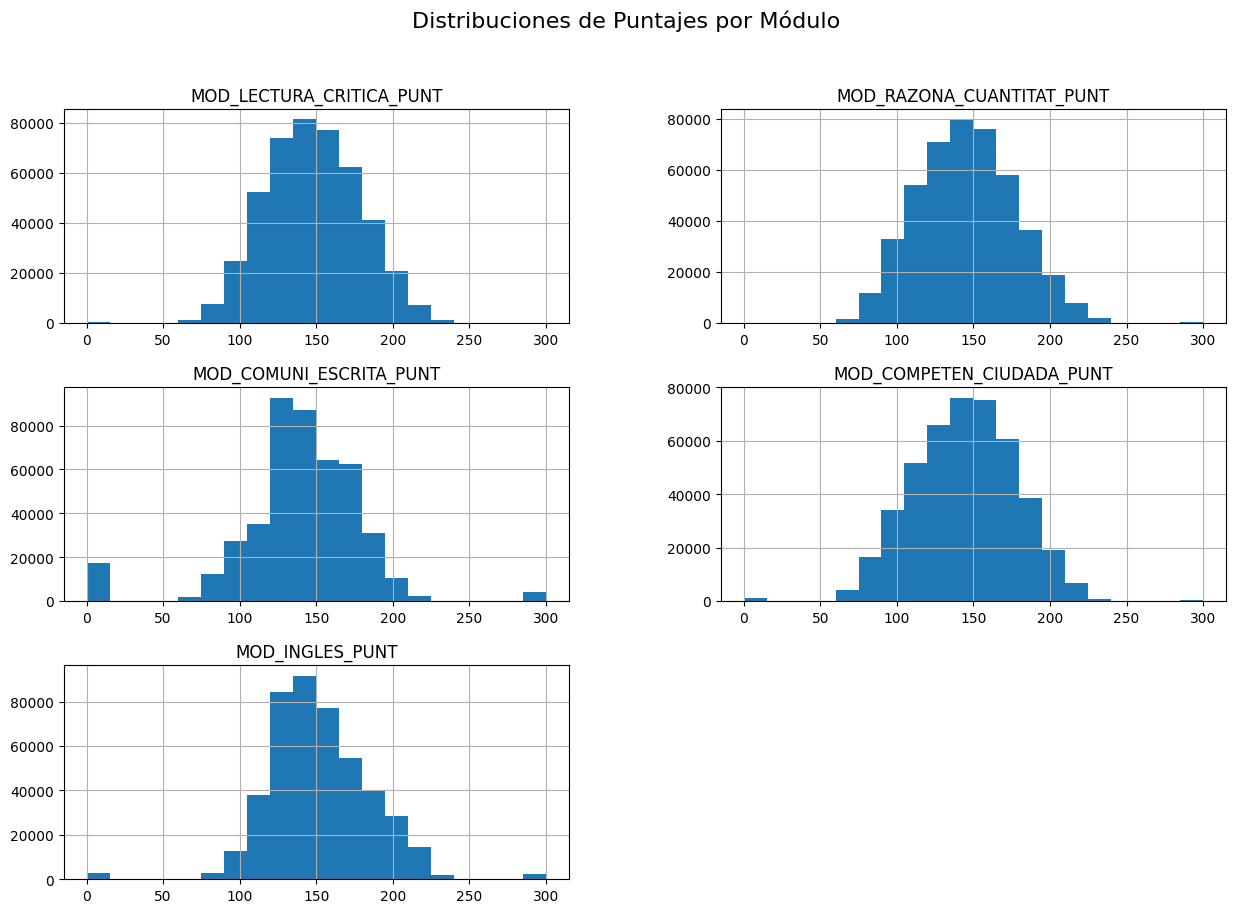

In [ ]:
# Análisis de sesgo y distribuciones
modulos = [
    "MOD_LECTURA_CRITICA_PUNT",
    "MOD_RAZONA_CUANTITAT_PUNT",
    "MOD_COMUNI_ESCRITA_PUNT",
    "MOD_COMPETEN_CIUDADA_PUNT",
    "MOD_INGLES_PUNT"
]

# Histogramas
df_cleaned_02[modulos].hist(bins=20, figsize=(15, 10))
plt.suptitle("Distribuciones de Puntajes por Módulo", fontsize=16)
plt.show()

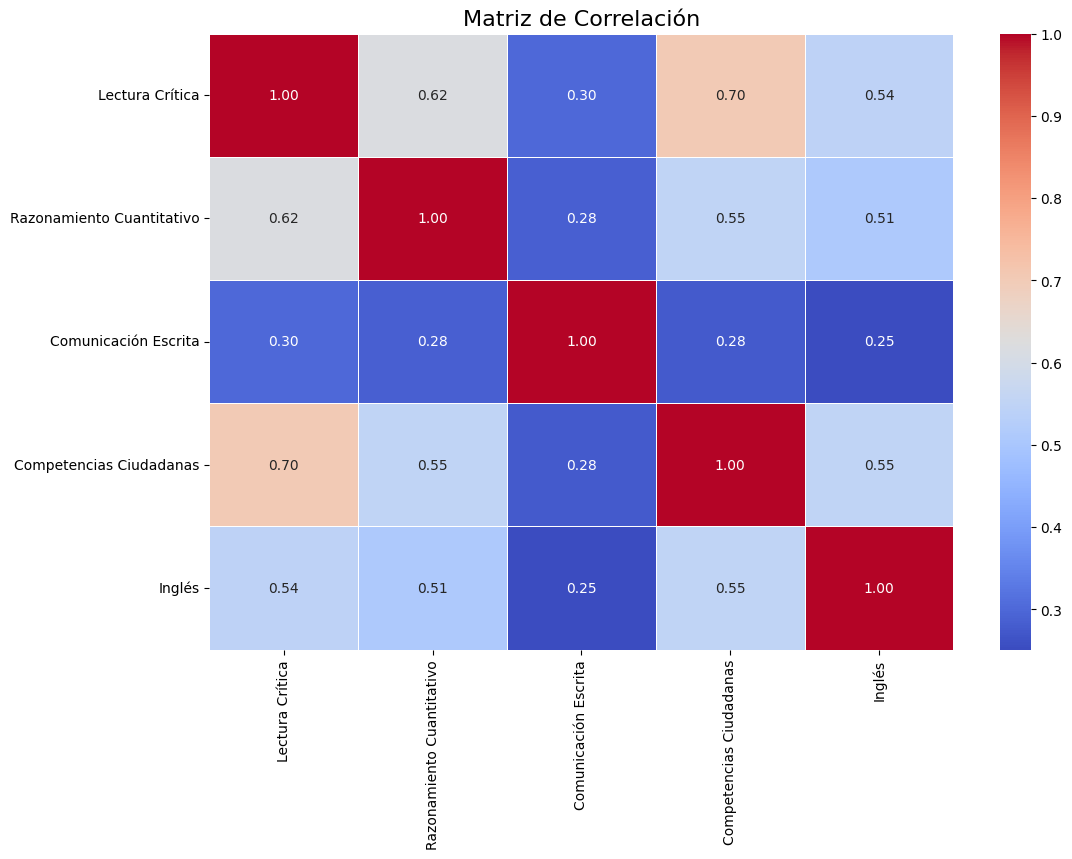

In [ ]:
# Diccionario
name_map = {
    "MOD_LECTURA_CRITICA_PUNT": "Lectura Crítica",
    "MOD_RAZONA_CUANTITAT_PUNT": "Razonamiento Cuantitativo",
    "MOD_COMUNI_ESCRITA_PUNT": "Comunicación Escrita",
    "MOD_COMPETEN_CIUDADA_PUNT": "Competencias Ciudadanas",
    "MOD_INGLES_PUNT": "Inglés",
}

# Matriz de correlación
correlation_matrix = df_cleaned_02[modulos].corr()
correlation_matrix = correlation_matrix.rename(index=name_map, columns=name_map)
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Matriz de Correlación", fontsize=16)
plt.show()

# Análisis de correlación y covarianza entre variables numéricas

### Variable PERIODO
- El **PERIODO** muestra correlaciones muy bajas con los puntajes de los módulos, lo que indica que, de manera lineal, el momento en que se presentó el examen no influye significativamente en el desempeño.  
- Sin embargo, se recomienda un análisis más profundo considerando factores externos asociados a los periodos. Por ejemplo, la pandemia de COVID-19 pudo haber generado variaciones en los resultados de los distintos módulos, lo que no necesariamente se refleja en una simple correlación lineal.


### Correlaciones entre módulos
- **Lectura Crítica y Competencias Ciudadanas**: correlación más alta (**0.7**), lo que sugiere que los estudiantes que se desempeñan bien en lectura crítica tienden también a hacerlo en competencias ciudadanas.  
- **Lectura Crítica y Razonamiento Cuantitativo**: correlación fuerte (**0.62**), indicando una relación relevante entre estas dos habilidades.  
- **Inglés y Competencias Ciudadanas / Razonamiento Cuantitativo**: correlaciones moderadas (**0.55 y 0.51**, respectivamente). Reflejan cierta relación positiva entre estas áreas, aunque no tan fuerte como en lectura crítica.  
- **Comunicación Escrita**: correlaciones más bajas con el resto de módulos (entre 0.28 y 0.30), lo que indica que su desempeño está menos relacionado con otras competencias.  

### Conclusiones
1. El **PERIODO no influye significativamente** en el rendimiento de los módulos, al menos desde una perspectiva lineal.  
2. Las **competencias de Lectura Crítica y Competencias Ciudadanas** muestran la relación más fuerte, lo que puede interpretarse como una cercanía conceptual en las habilidades que evalúan.  
3. El **Módulo de Comunicación Escrita es el más independiente**, con correlaciones débiles respecto a los demás.  
4. En general, las correlaciones positivas entre módulos sugieren que existe un perfil de estudiante que rinde de forma consistente en varias áreas, aunque las magnitudes varían según la competencia.  


# Tablas de contingencia para variables categóricas

In [ ]:
# Tablas de contingencia
for col in categorical_columns:
    print(f"Tabla de Contingencia para {col}:")
    print(pd.crosstab(df_cleaned_02[col], columns="Frecuencia"))
    print("\n")

Tabla de Contingencia para INST_NOMBRE_INSTITUCION:
col_0                                               Frecuencia
INST_NOMBRE_INSTITUCION                                       
CENTRO DE EDUCACION MILITAR-BOGOTÁ D.C.                    104
COLEGIO DE ESTUDIOS SUPERIORES DE ADMINISTRACIO...        1052
COLEGIO MAYOR DE NUESTRA SEÑORA DEL ROSARIO-BOG...        6808
CORPORACION ESCUELA DE ARTES Y LETRAS-BOGOTÁ D.C.         1026
CORPORACION INTERNACIONAL PARA EL DESARROLLO ED...         229
...                                                        ...
UNIVERSIDAD SANTO TOMAS-BOGOTÁ D.C.                      10357
UNIVERSIDAD SERGIO ARBOLEDA-BOGOTÁ D.C.                   3296
UNIVERSIDAD-COLEGIO MAYOR DE CUNDINAMARCA-BOGOT...        3282
UNIVERSITARIA AGUSTINIANA- UNIAGUSTINIANA-BOGOT...        4135
UNIVERSITARIA VIRTUAL INTERNACIONAL-BOGOTÁ D.C.            370

[83 rows x 1 columns]


Tabla de Contingencia para INST_CARACTER_ACADEMICO:
col_0                      Frecuencia
INST_CARACTER_

# Gráficos de Barras para las variables catégoricas

**Distribución por tipo de institución**  
Se observa que la mayoría de los estudiantes que presentan la prueba provienen de instituciones universitarias y universidades, superando los 200.000 participantes. En contraste, las instituciones técnicas profesionales y tecnológicas registran una participación significativamente menor, que no supera los 25.000 estudiantes. Esta distribución se evidencia en los 5 años analizados, con algunas variaciones en cada uno.


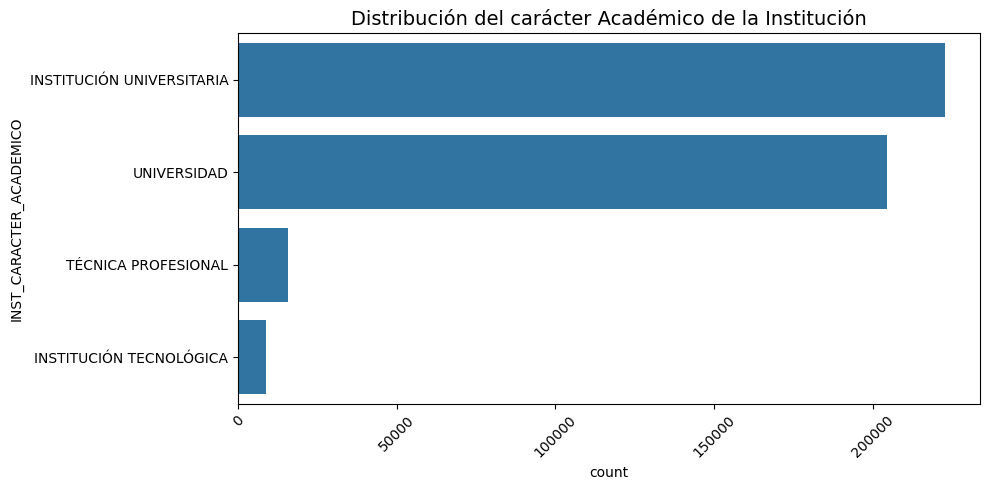

In [ ]:
#Gráfico
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_cleaned_02,
    y="INST_CARACTER_ACADEMICO",
    order=df_cleaned_02["INST_CARACTER_ACADEMICO"].value_counts().index
)
plt.title("Distribución del carácter Académico de la Institución", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Distribución por pregrado**  
* Se evidencia una gran participación de estudiantes de pregrado en Administración **(140.000)**, seguido por Psicología, Contaduría, Educación, Derecho e Ingeniería Industrial **(30.000–50.000)**.  Luego aparecen Ingeniería Civil, Economía, Arquitectura, Medicina, Diseño, entre otros.  

* La curva que se forma negativamente muestra una distribución exponencial, donde existen muchos pregrados con pocos estudiantes, incluso llegando a ser menos de **1.000.** Esto indica que una gran parte de las pruebas la presentan estudiantes de las mismas carreras.

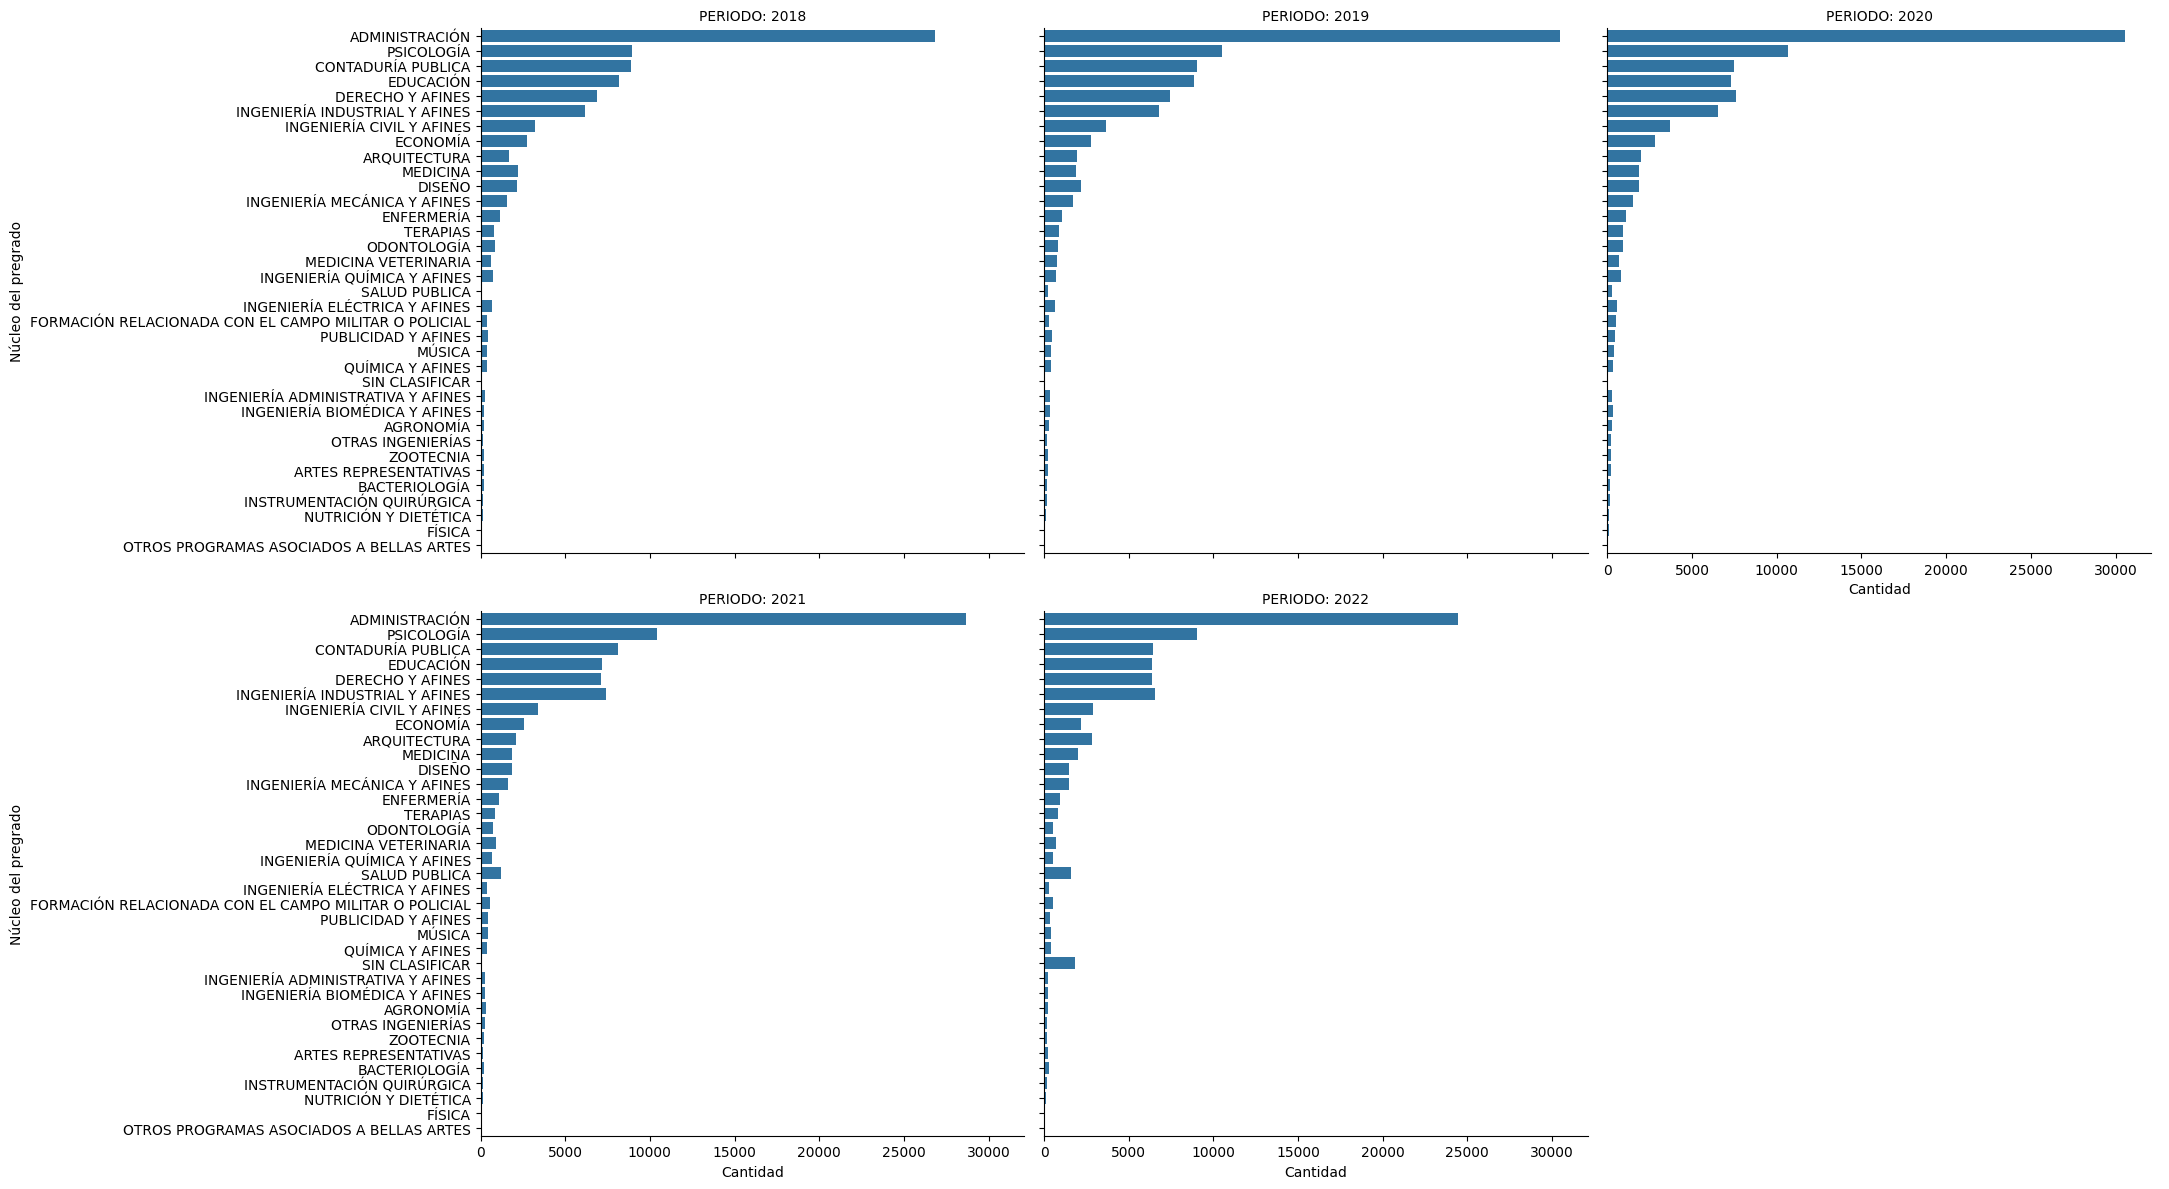

In [ ]:
g = sns.catplot(
    data=df_cleaned_02,
    kind="count",
    y="ESTU_NUCLEO_PREGRADO",
    order=df_cleaned_02["ESTU_NUCLEO_PREGRADO"].value_counts().index,
    col="PERIODO",
    col_wrap=3,
    height=6,
    aspect=1.2
)
g.set_titles("PERIODO: {col_name}")
g.set_axis_labels("Cantidad", "Núcleo del pregrado")
plt.tight_layout()
plt.show()

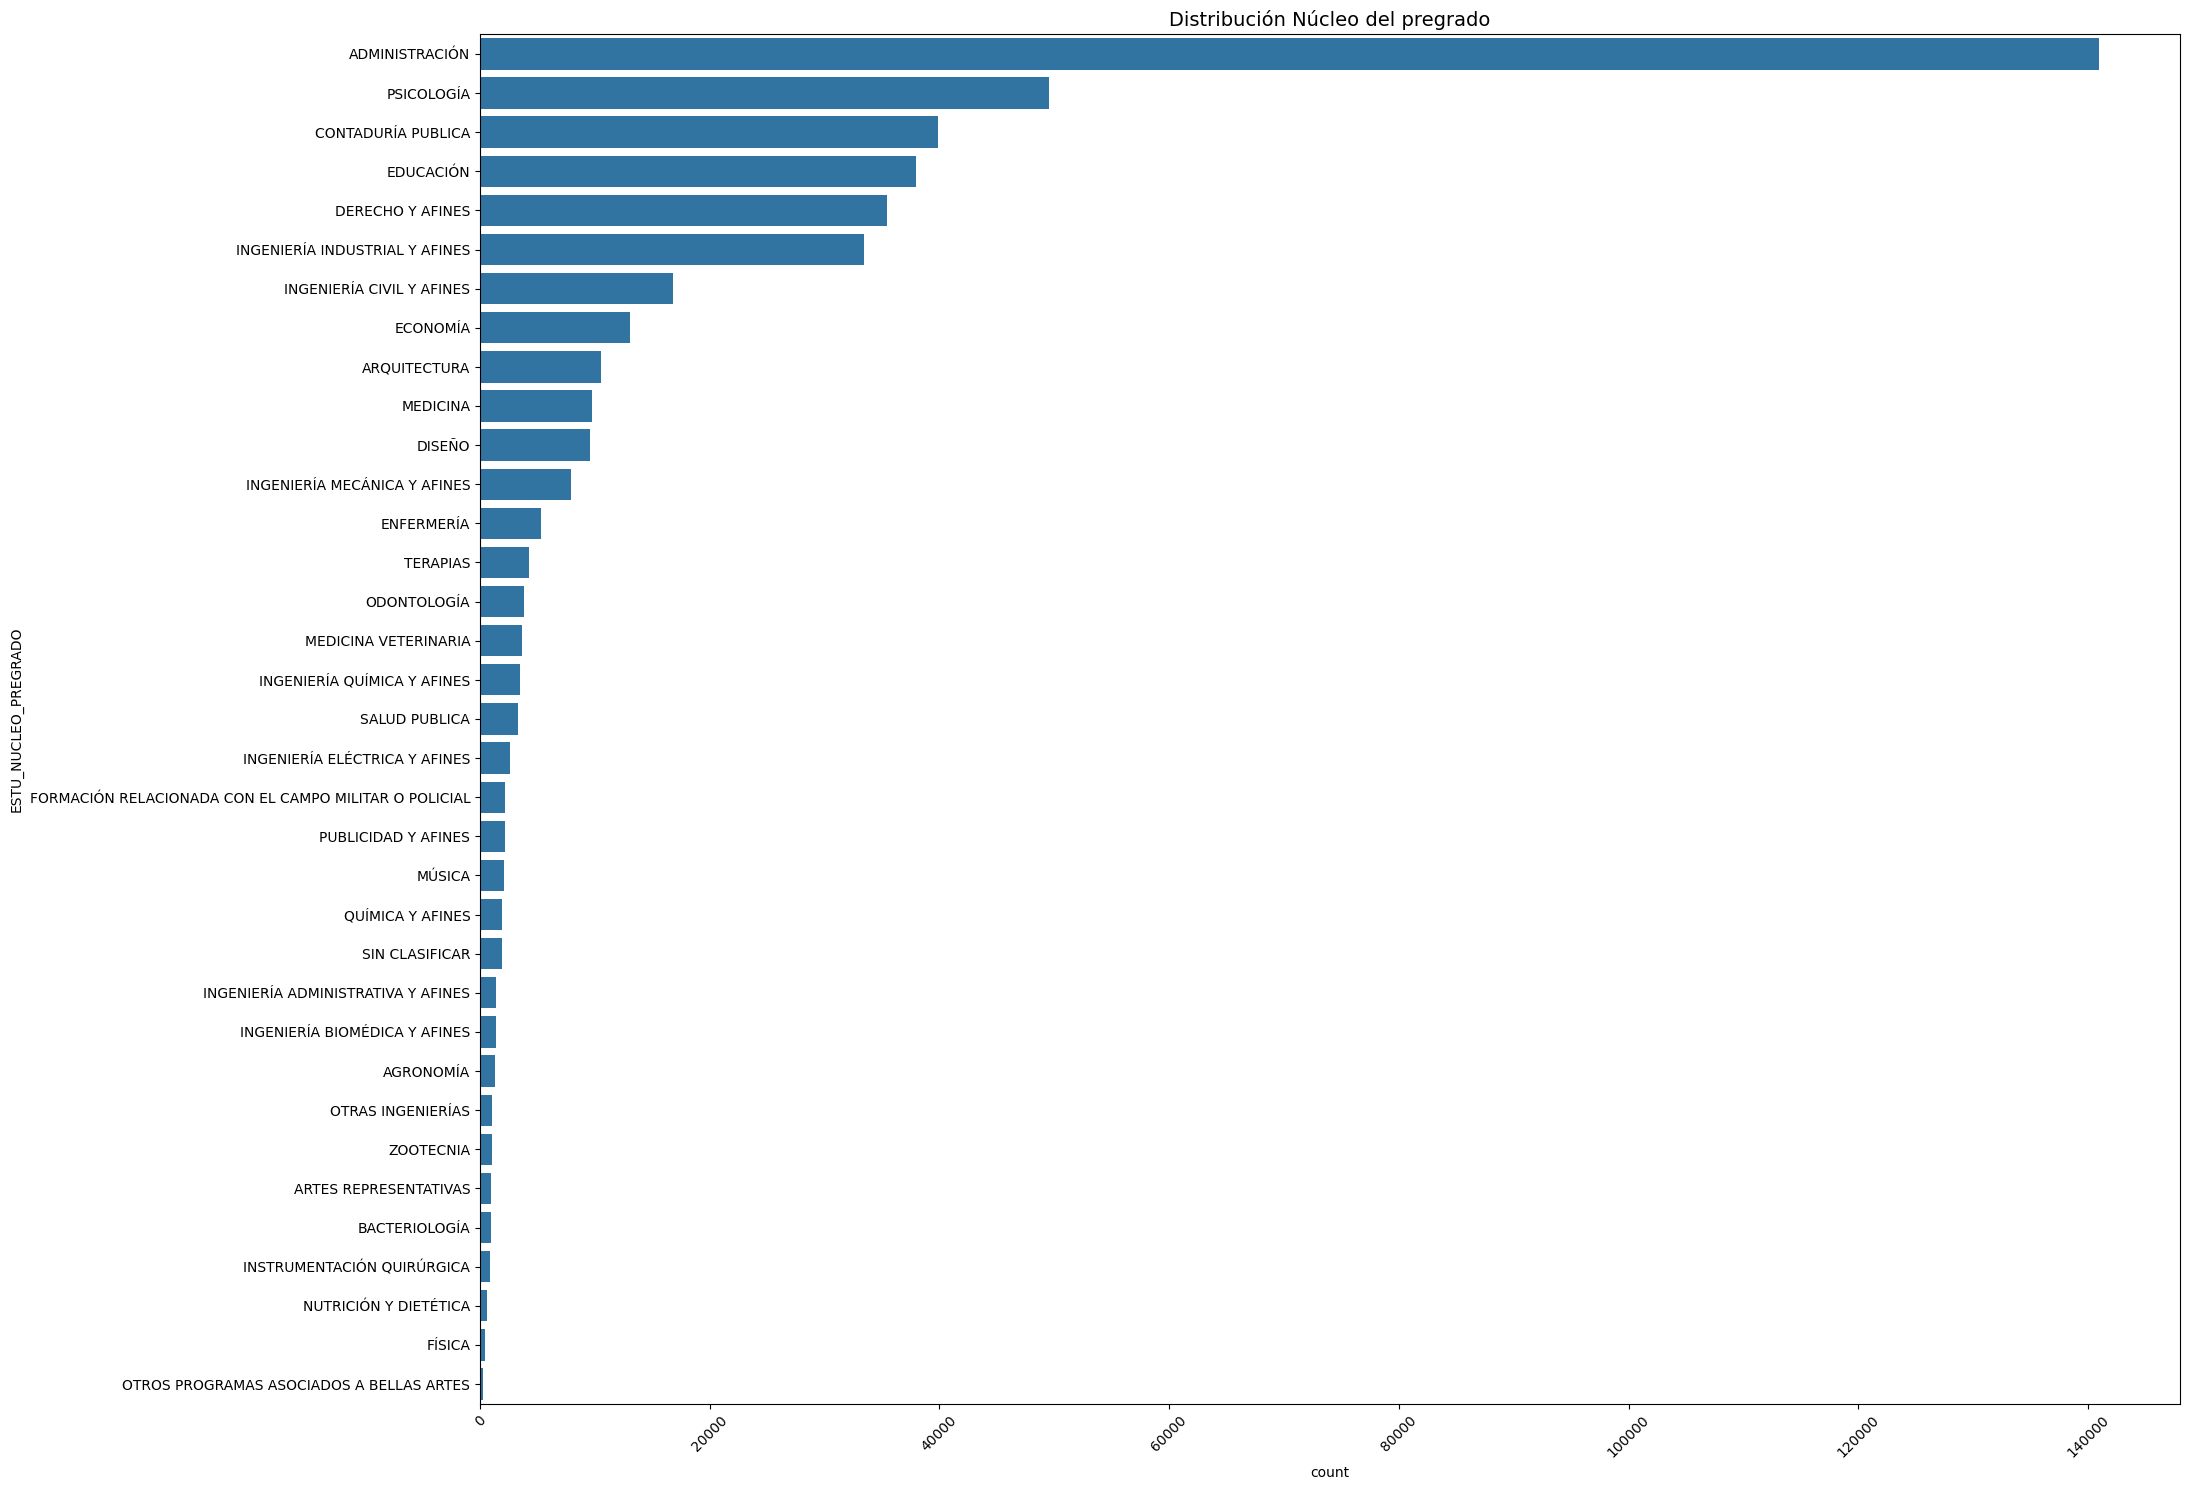

In [ ]:
#Gráfico
plt.figure(figsize=(22,15))
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_NUCLEO_PREGRADO",
    order=df_cleaned_02["ESTU_NUCLEO_PREGRADO"].value_counts().index
)
plt.title("Distribución Núcleo del pregrado", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Modalidad de estudio**  
* El gráfico sugiere que existe una cantidad similar de estudiantes que estudian de forma presencial y virtual y/o a distancia (donde la modalidad distancia y distancia virtual son iguales).  
* Esto permitirá al modelo tener en cuenta en igual proporción ambos grupos de estudiantes.


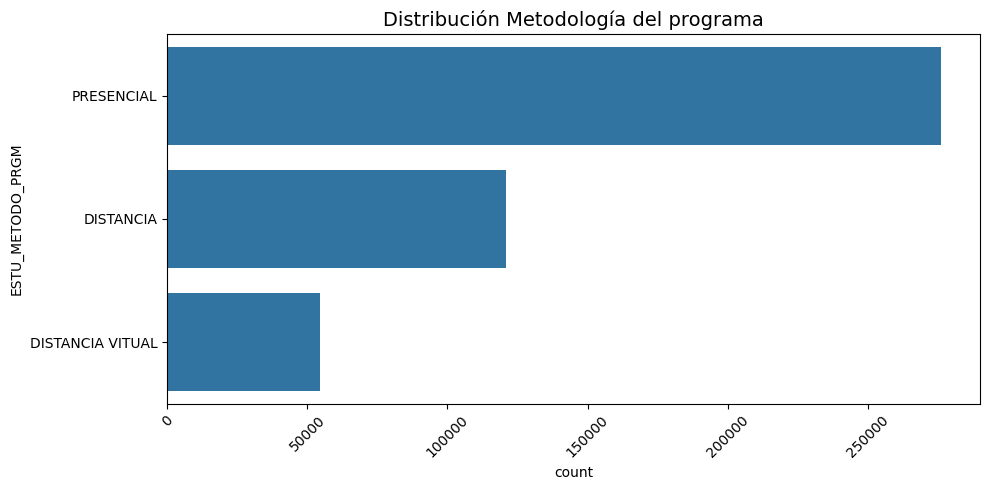

In [ ]:
#Gráfico
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_METODO_PRGM",
    order=df_cleaned_02["ESTU_METODO_PRGM"].value_counts().index
)
plt.title("Distribución Metodología del programa", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Costo de matrícula en pregrado**  
* Paralelamente con el pregrado, la mayoría de estudiantes paga un valor entre 1 millón y 2.5 millones de matrícula (175.000 estudiantes).  
* Un poco más de 150.000 estudiantes pagan entre 2.5 y 7 millones.  
* Muy pocos estudiantes no pagan matrícula o menos de 1 millón (menos de 75.000 estudiantes). Tan solo 50.000 pagan más de 7 millones.

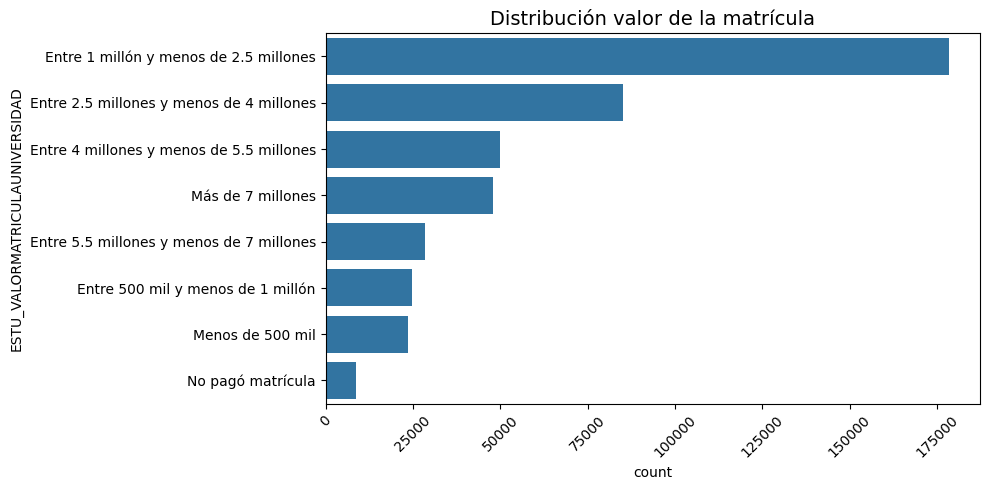

In [ ]:
#Gráfico
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_VALORMATRICULAUNIVERSIDAD",
    order=df_cleaned_02["ESTU_VALORMATRICULAUNIVERSIDAD"].value_counts().index
)
plt.title("Distribución valor de la matrícula", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Formas de pago de matrícula**  
* Del total de estudiantes, menos de 80.000 pagan la matrícula con beca, opuesto a los más de 350.000 que la pagan sin ella.  
Paralelamente, entre 150.000 y 200.000 estudiantes pagan la matrícula con un crédito (cerca al 50% del total), frente a los casi 300.000 que no lo hacen.  

* Ambos gráficos reflejan que más del 50% de los estudiantes de educación superior pagan su matrícula por medio de créditos y/o becas, lo cual evidencia la falta de recursos para costear en su totalidad la matrícula.


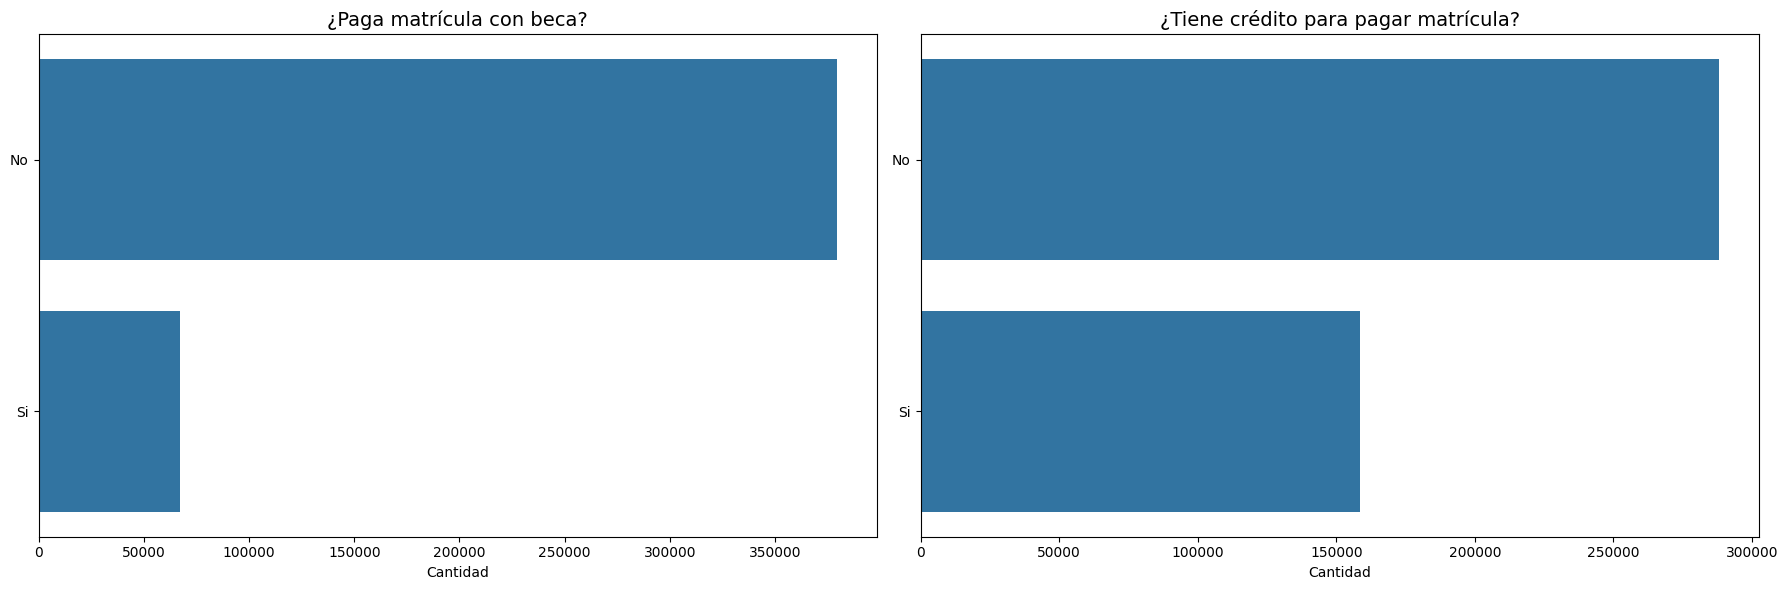

In [ ]:
# Grafico de pago de matricula (BECA - CREDITO)
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Beca
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_PAGOMATRICULABECA",
    order=df_cleaned_02["ESTU_PAGOMATRICULABECA"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("¿Paga matrícula con beca?", fontsize=14)
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("")

# Credito
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_PAGOMATRICULACREDITO",
    order=df_cleaned_02["ESTU_PAGOMATRICULACREDITO"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("¿Tiene crédito para pagar matrícula?", fontsize=14)
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Estudiantes que trabajan**  
* 200.000 estudiantes trabajan más de 30 horas por semana.  
* Entre 50.000 y 75.000 trabajan entre 11–20 y 21–30 horas.  
* Menos de 60.000 trabajan 10 horas.  
* solo entre el 10%–15% de los estudiantes no trabajan.

Esto implica, sumado al análisis del precio de la matrícula y el uso de becas o créditos, que muchos estudiantes no cuentan con recursos suficientes y trabajan paralelamente para pagar los gastos.  

Hay que tener en cuenta que estos datos corresponden solo a estudiantes de Bogotá, donde el acceso a créditos y becas es más accesible. En otras ciudades del país estos patrones pueden ser más elevados.


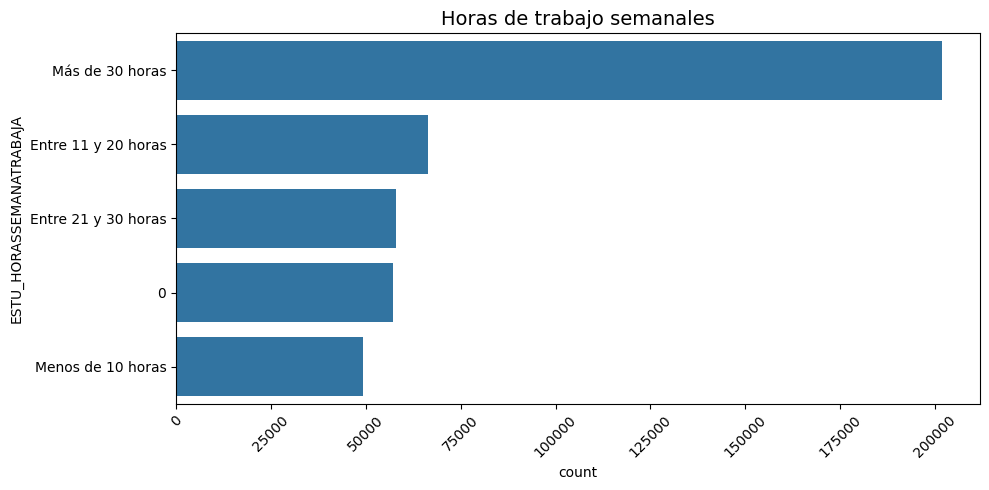

In [ ]:
#Gráfico
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_HORASSEMANATRABAJA",
    order=df_cleaned_02["ESTU_HORASSEMANATRABAJA"].value_counts().index
)
plt.title("Horas de trabajo semanales", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Estudiantes privados de la libertad**  
* Menos del 10% de los estudiantes están privados de la libertad. Esto implica una limitación para el modelo, puesto que el espacio de hipótesis se reduce a solo estudiantes en libertad, dado que no se tienen datos suficientes para que el modelo aprenda de estos casos.


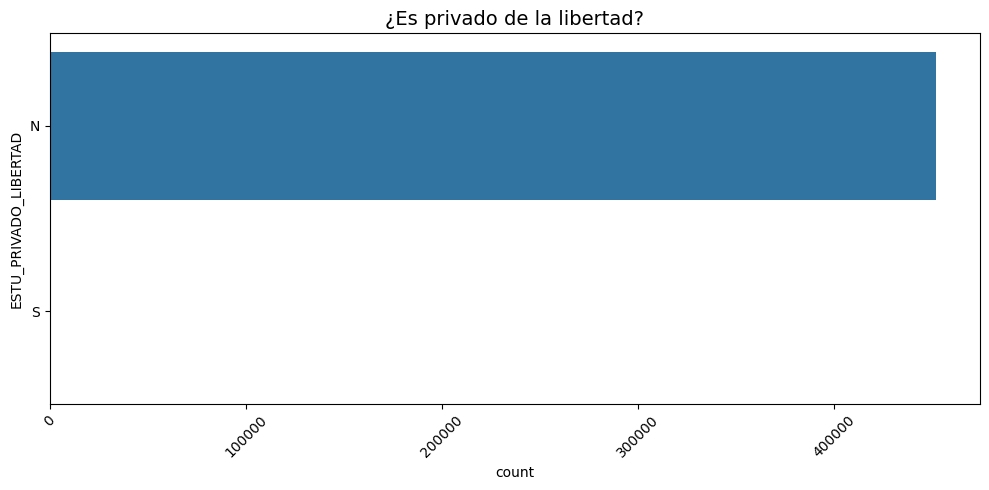

In [ ]:
#Gráfico
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_PRIVADO_LIBERTAD",
    order=df_cleaned_02["ESTU_PRIVADO_LIBERTAD"].value_counts().index
)
plt.title("¿Es privado de la libertad?", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Distribución por género**  
* Se muestra que más de 250.000 estudiantes que presentaron la prueba son de género femenino, opuestos a los menos de 175.000 que son de género masculino.  
* Aunque la diferencia es significativa, no se pierde información en el modelo, puesto que existen suficientes muestras de ambos grupos para hacer conclusiones e interpretaciones robustas.


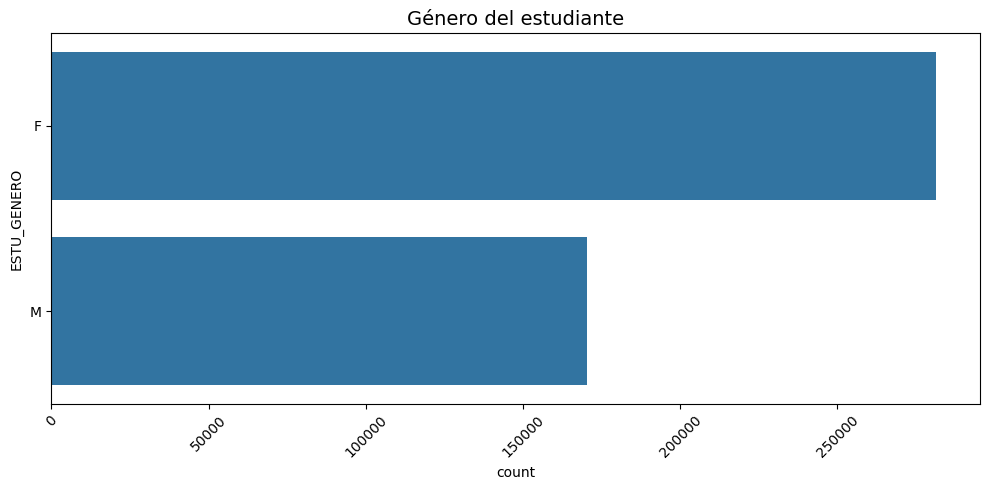

In [ ]:
#Gráfico
plt.figure(figsize=(10,5))
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_GENERO",
    order=df_cleaned_02["ESTU_GENERO"].value_counts().index
)
plt.title("Género del estudiante", fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Relación entre quién paga la matrícula**  
* Cerca de 250.000 estudiantes pagan directamente su matrícula, lo que corresponde a poco más del 50%, mostrando una relación inversa: cuando los padres no pagan, el estudiante mismo suele asumir el costo.  

* Esto puede estar reflejando que las becas o créditos no alcanzan a cubrir la mayoría de casos, y por lo tanto la responsabilidad se distribuye entre padres y estudiantes.  



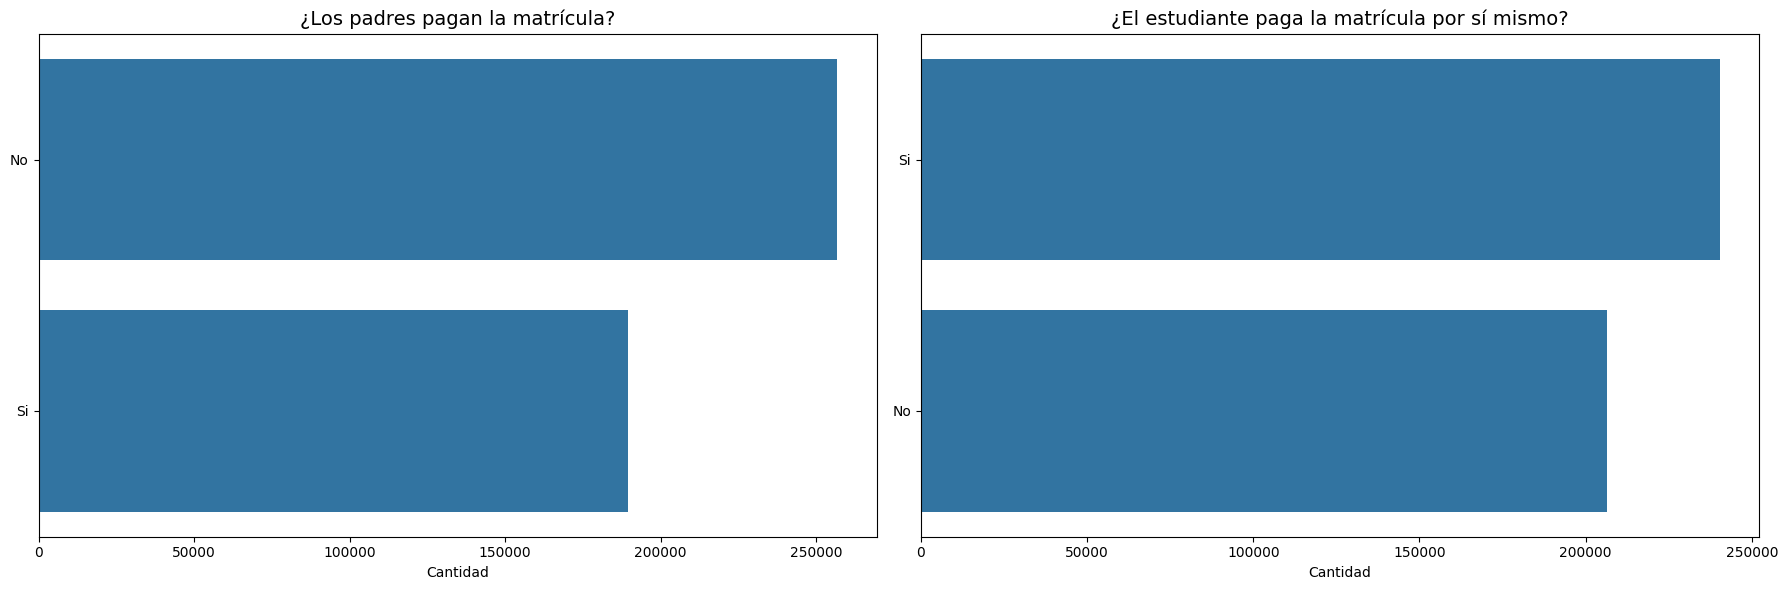

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)

# Padres pagan
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_PAGOMATRICULAPADRES",
    order=df_cleaned_02["ESTU_PAGOMATRICULAPADRES"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("¿Los padres pagan la matrícula?", fontsize=14)
axes[0].set_xlabel("Cantidad")
axes[0].set_ylabel("")

# Estudiante paga
sns.countplot(
    data=df_cleaned_02,
    y="ESTU_PAGOMATRICULAPROPIO",
    order=df_cleaned_02["ESTU_PAGOMATRICULAPROPIO"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("¿El estudiante paga la matrícula por sí mismo?", fontsize=14)
axes[1].set_xlabel("Cantidad")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

**Nivel educativo de los padres**  
* En el gráfico del nivel de estudio de la madre se evidencia que menos de 100.000 terminaron la secundaria, y en el caso del padre es menos de 80.000.  
* La primaria completa es cercana a los 50.000 en ambos.  
* Menos de 40.000 tienen un posgrado.  
* Menos de 20.000 corresponden a "no aplica", "no sabe" o "ninguno".  

* Esto refleja también un difícil acceso a la educación superior. Entre 40.000 y 60.000 terminaron una educación profesional y menos aún posgrados.  

Sería interesante un análisis temporal de la finalización de estudios en las últimas décadas, para identificar si la tendencia observada en estos 5 años se mantiene en educación primaria y media, evidenciando mayor dificultad para ingresar y mantenerse en la educación superior.


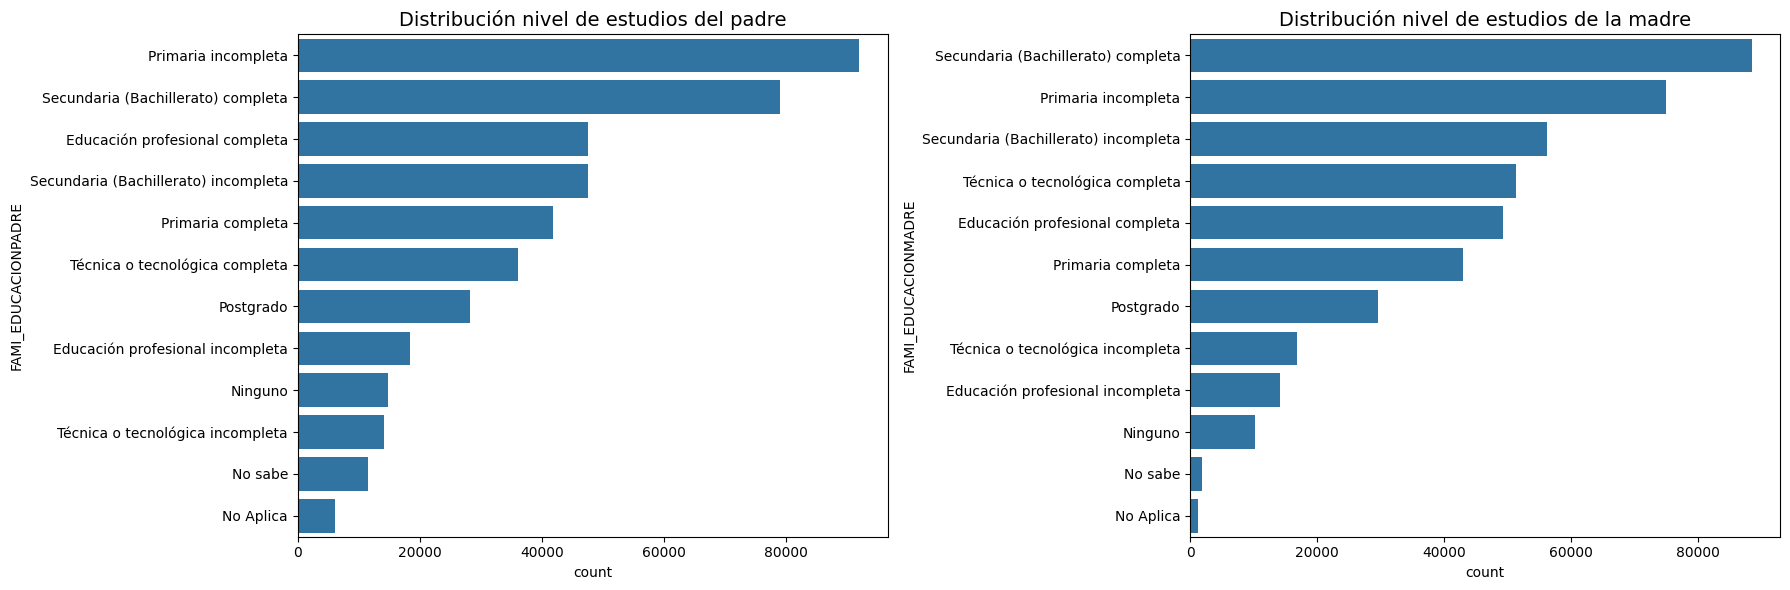

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharex=False)

# Gráfico 1
sns.countplot(
    data=df_cleaned_02,
    y="FAMI_EDUCACIONPADRE",
    order=df_cleaned_02["FAMI_EDUCACIONPADRE"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Distribución nivel de estudios del padre", fontsize=14)

# Gráfico 2
sns.countplot(
    data=df_cleaned_02,
    y="FAMI_EDUCACIONMADRE",
    order=df_cleaned_02["FAMI_EDUCACIONMADRE"].value_counts().index,
    ax=axes[1]
)
axes[1].set_title("Distribución nivel de estudios de la madre", fontsize=14)


plt.tight_layout()
plt.show()

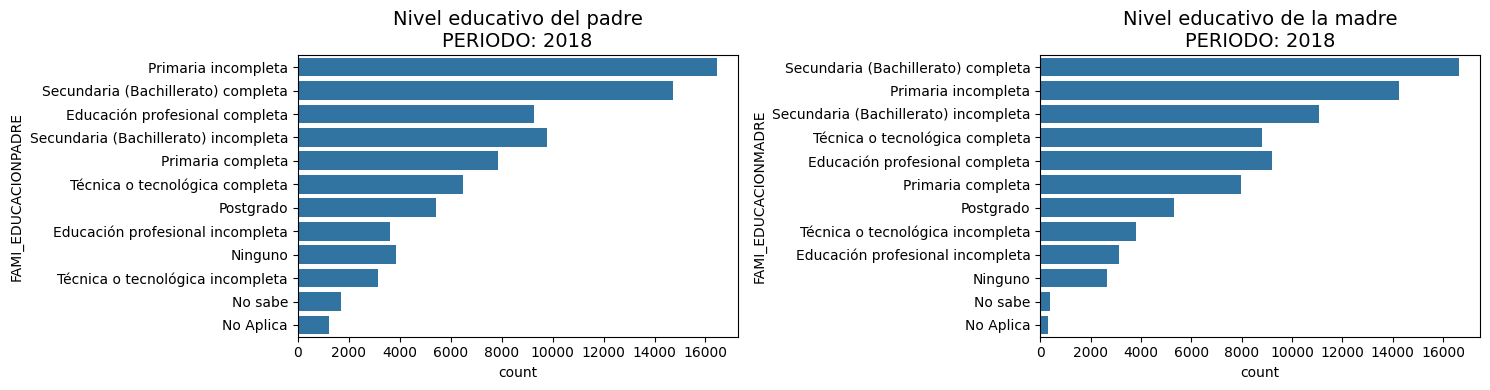

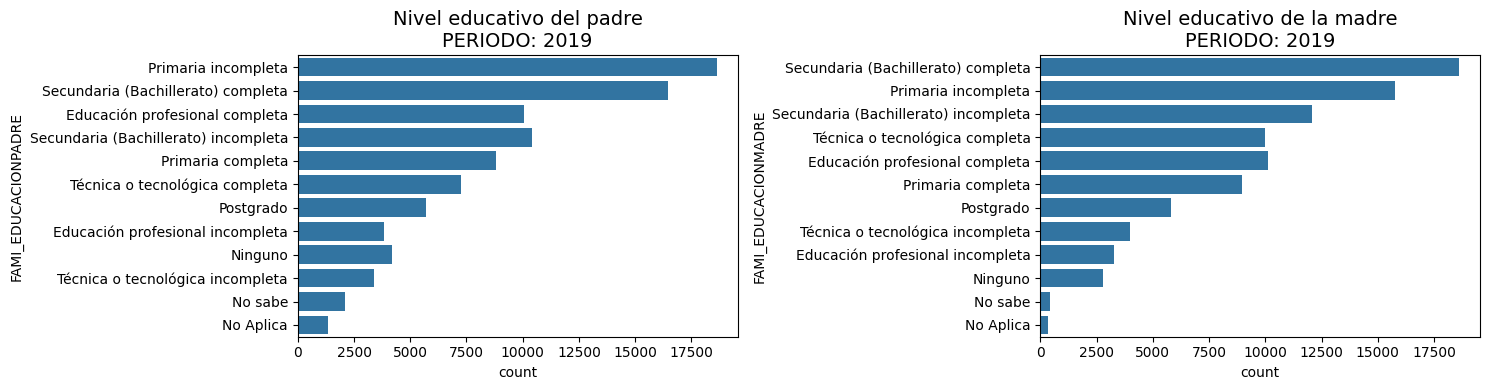

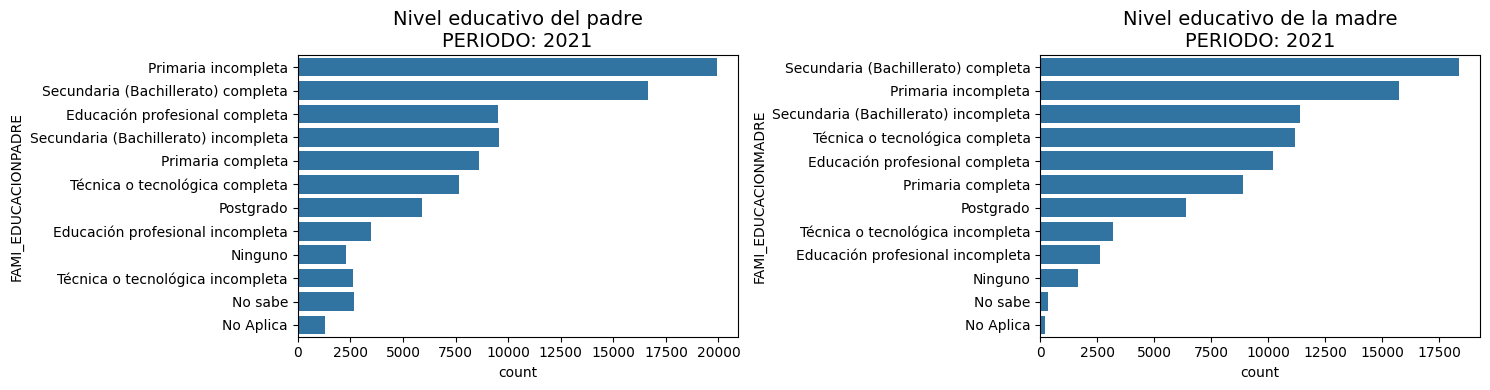

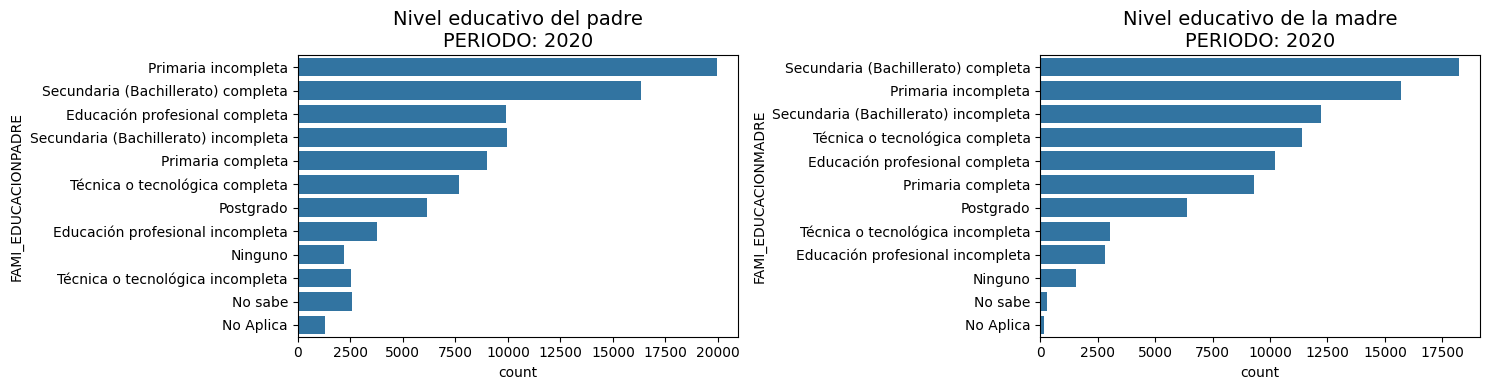

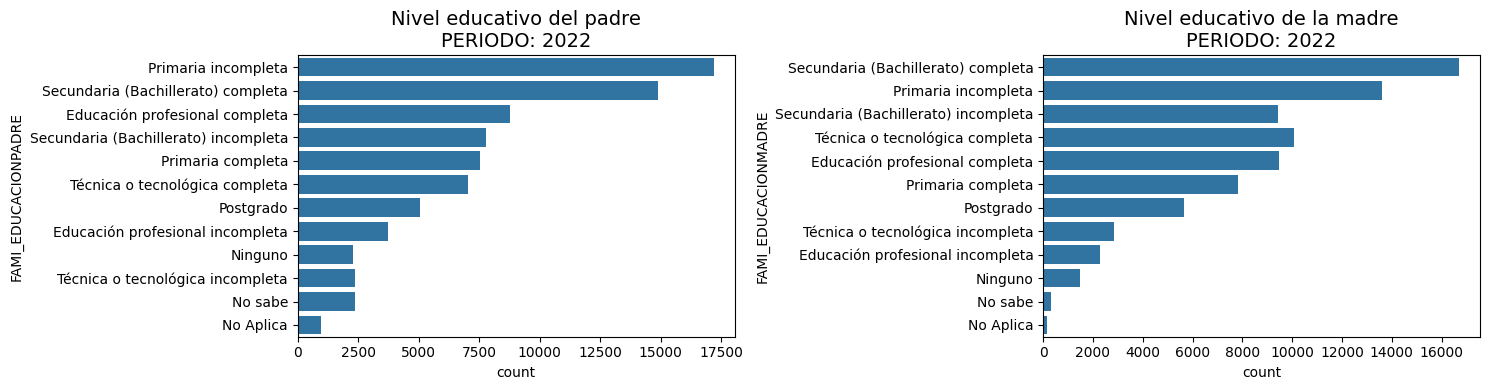

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Lista de periodos únicos
periodos = df_cleaned_02["PERIODO"].unique()

# Crear un gráfico por cada PERIODO
for periodo in periodos:
    # Filtrar datos por periodo
    df_periodo = df_cleaned_02[df_cleaned_02["PERIODO"] == periodo]

    # Crear figura con 2 gráficos lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharex=False)

    # --- Gráfico 1: Educación del padre ---
    sns.countplot(
        data=df_periodo,
        y="FAMI_EDUCACIONPADRE",
        order=df_cleaned_02["FAMI_EDUCACIONPADRE"].value_counts().index,
        ax=axes[0]
    )
    axes[0].set_title(f"Nivel educativo del padre\nPERIODO: {periodo}", fontsize=14)

    # --- Gráfico 2: Educación de la madre ---
    sns.countplot(
        data=df_periodo,
        y="FAMI_EDUCACIONMADRE",
        order=df_cleaned_02["FAMI_EDUCACIONMADRE"].value_counts().index,
        ax=axes[1]
    )
    axes[1].set_title(f"Nivel educativo de la madre\nPERIODO: {periodo}", fontsize=14)

    plt.tight_layout()
    plt.show()


**Estrato Socieconomico**

* Entre **150.000 y 160.000 estudiantes** pertenecen al **estrato socioeconómico 2 o 3**, mientras que **menos de 60.000** corresponden al **estrato 1**.  
* En conjunto, **más del 50% de los estudiantes** provienen de los estratos **1, 2 y 3**.  

* Por otro lado, únicamente **40.000 estudiantes** pertenecen al **estrato 4**, y **menos de 20.000** se ubican en los **estratos 5 y 6**.  

Esto evidencia que la **mayoría de los estudiantes provienen de estratos bajos y medios**.


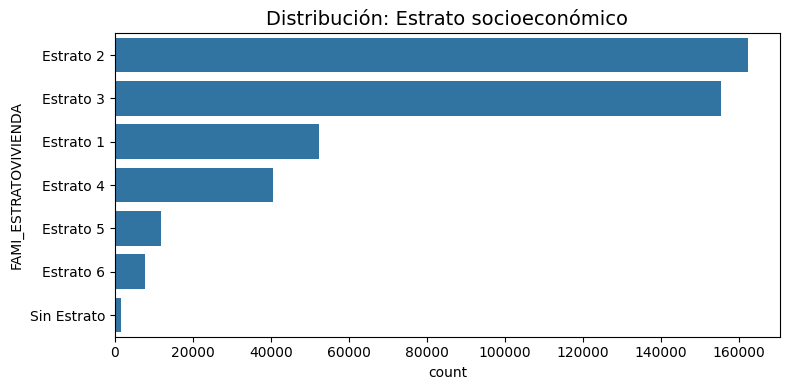

In [ ]:
# Estrato Socieconomico
plt.figure(figsize=(8,4))
sns.countplot(
    data=df_cleaned_02,
    y="FAMI_ESTRATOVIVIENDA",
    order=df_cleaned_02["FAMI_ESTRATOVIVIENDA"].value_counts().index
)
plt.title("Distribución: Estrato socioeconómico", fontsize=14)
plt.tight_layout()
plt.show()


**Estrato Socioeconómico**

En los módulos de la prueba (Lectura Crítica, Razonamiento Cuantitativo, Competencias Ciudadanas, Comunicación Escrita e Inglés) se observa una relación clara entre el puntaje obtenido y el estrato socioeconómico del estudiante.

A medida que aumenta el estrato, también lo hacen la **media, los valores máximos y mínimos de los puntajes**, lo que refleja cómo un mayor nivel socioeconómico se asocia con **mejores recursos educativos**. Esto implica menos necesidad de trabajar extensas jornadas, menor dependencia de créditos o becas, y una carga económica familiar reducida.

El caso más evidente se da en el módulo de **Inglés**:  
- Los estudiantes de estratos 1 y 2 presentan medianas cercanas a **150 puntos**.  
- En contraste, los de estratos 5 y 6 alcanzan medianas cercanas a **200 puntos**.  

Aunque existen valores atípicos en todos los grupos, la tendencia confirma que el **estrato socioeconómico es un factor determinante en el desempeño académico**.


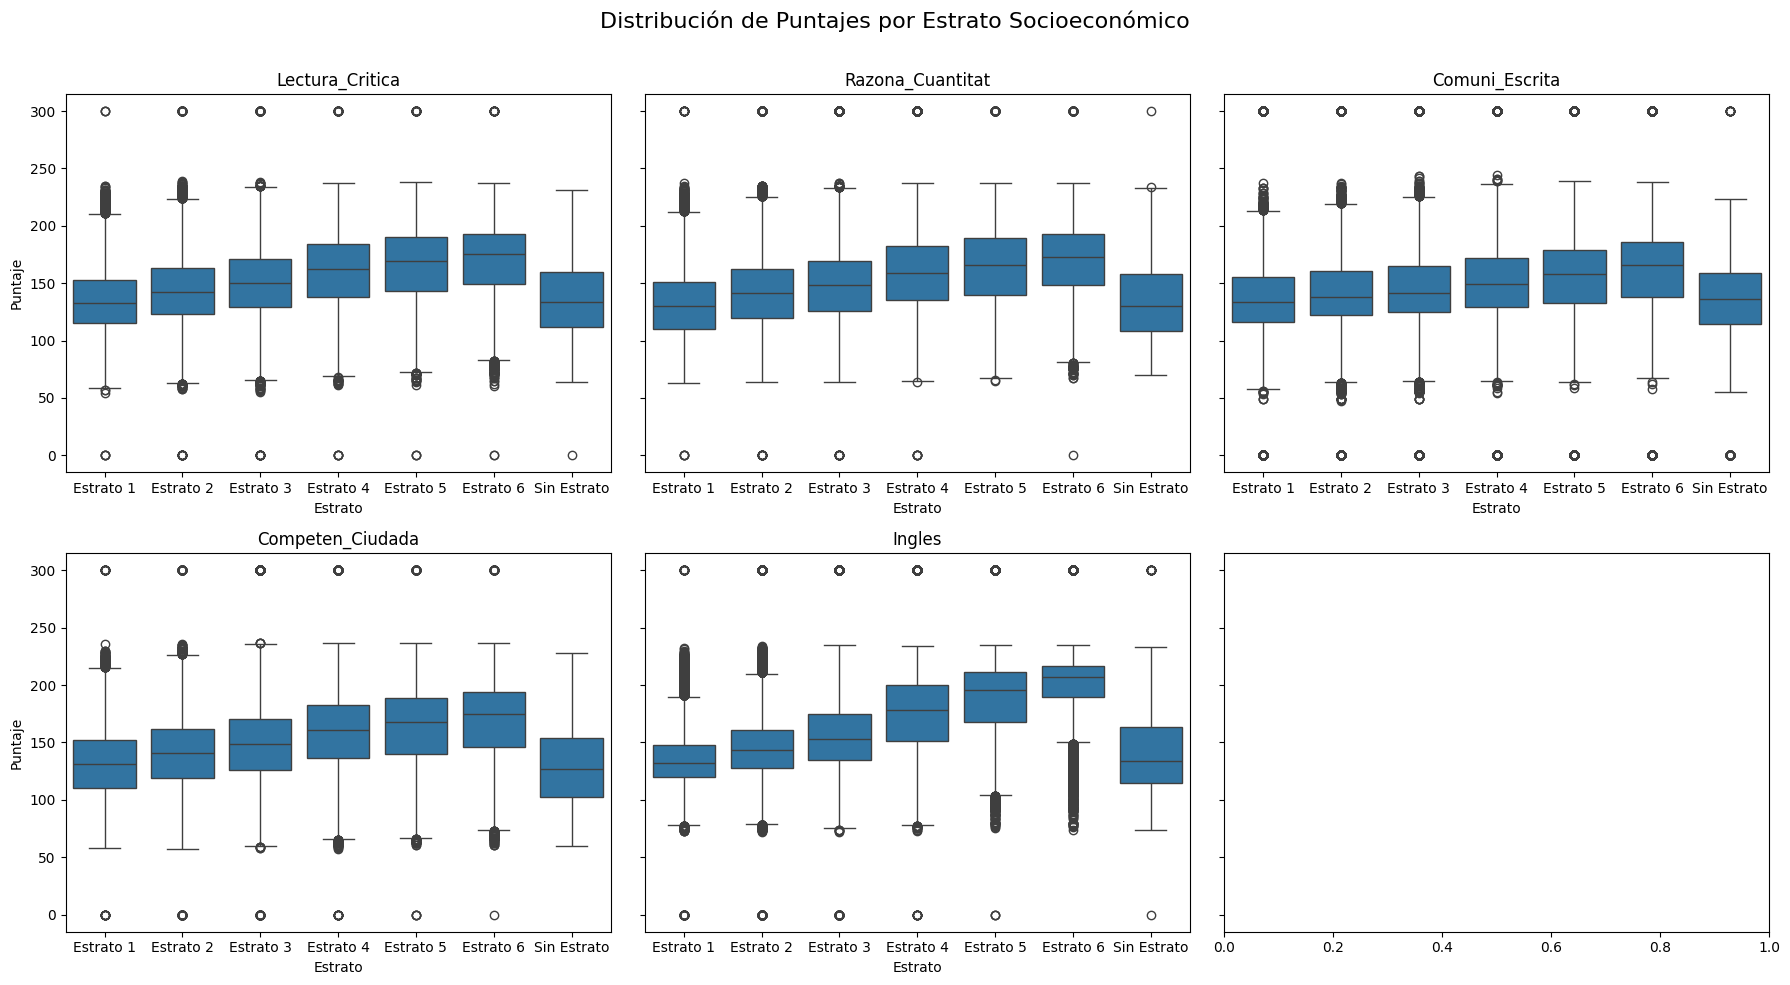

In [ ]:
# Lista de módulos
modulos = [
    "MOD_LECTURA_CRITICA_PUNT",
    "MOD_RAZONA_CUANTITAT_PUNT",
    "MOD_COMUNI_ESCRITA_PUNT",
    "MOD_COMPETEN_CIUDADA_PUNT",
    "MOD_INGLES_PUNT"
]

cols = 3
rows = math.ceil(len(modulos) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows), sharey=True)
axes = axes.flatten()

# Modulo por estrato
for i, mod in enumerate(modulos):
    sns.boxplot(
        data=df_cleaned_02,
        x="FAMI_ESTRATOVIVIENDA",
        y=mod,
        order=sorted(df_cleaned_02["FAMI_ESTRATOVIVIENDA"].dropna().unique()),
        ax=axes[i]
    )
    axes[i].set_title(mod.replace("MOD_", "").replace("_PUNT", "").title())
    axes[i].set_xlabel("Estrato")
    if i % cols == 0:
        axes[i].set_ylabel("Puntaje")
    else:
        axes[i].set_ylabel("")

plt.suptitle("Distribución de Puntajes por Estrato Socioeconómico", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

In [ ]:
# Descargar dataset limpio
# df_cleaned_02.to_csv('/content/drive/MyDrive/Proyecto_Tecnicas_ML/df_cleaned_02.csv', index=False)

# Análisis de Calidad de Datos

## 1. Total de valores nulos
* El DataFrame contiene **187.269 valores faltantes en total**, lo que representa un volumen considerable, aunque su distribución depende de cada variable.

## 2. Columnas sin valores faltantes
* Variables como `PERIODO`, `INST_NOMBRE_INSTITUCION`, `INST_CARACTER_ACADEMICO`, `ESTU_NUCLEO_PREGRADO`, `ESTU_METODO_PRGM`, `ESTU_PRIVADO_LIBERTAD`, `MOD_RAZONA_CUANTITAT_PUNT`, `MOD_LECTURA_CRITICA_PUNT` y `MOD_COMPETEN_CIUDADA_PUNT` no presentan **ningún dato nulo**, lo que asegura confiabilidad en esas dimensiones.

## 3. Columnas con valores nulos mínimos (menos del 2%)
* `ESTU_VALORMATRICULAUNIVERSIDAD`, `ESTU_PAGOMATRICULABECA`, `ESTU_PAGOMATRICULACREDITO`, `ESTU_PAGOMATRICULAPADRES`, `ESTU_PAGOMATRICULAPROPIO`, `ESTU_GENERO`, `MOD_COMUNI_ESCRITA_PUNT`, `MOD_INGLES_PUNT`.

  * Estas tasas son bajas y no deberían comprometer el análisis general. Podrían manejarse mediante **imputación simple** (moda, mediana) o directamente con eliminación de registros, según el tamaño del dataset.

## 4. Columnas con valores nulos moderados (3% a 6%)
* `ESTU_HORASSEMANATRABAJA`, `FAMI_EDUCACIONPADRE`, `FAMI_EDUCACIONMADRE`, `FAMI_ESTRATOVIVIENDA`, `FAMI_TIENEINTERNET`, `FAMI_TIENECOMPUTADOR`, `FAMI_TIENELAVADORA`, `FAMI_TIENEAUTOMOVIL`.

  * Aquí la proporción de nulos es mayor sin ser alarmante o dañino para el analisis. El hecho de que varias pertenezcan al **bloque de condiciones familiares (FAMI_)** sugiere que algunos estudiantes omitieron esta sección de la encuesta.
  * Dependiendo del análisis, se podrían usar técnicas como:
    * **Imputación basada en la moda** (para variables categóricas binomiales como Sí/No).
    * **Agrupación en una categoría adicional** (“No reportado”) para evitar sesgos.

## 5. Observación general
* En términos globales, el dataset tiene **buena calidad**:
  * Las variables principales de desempeño académico (`MOD_*`) están casi completas.
  * Los valores nulos se concentran en **características socioeconómicas y familiares**.
* El volumen de nulos no es lo suficientemente alto como para comprometer la validez del análisis, pero sí requiere **una estrategia clara de imputación** para evitar sesgos en los modelos.

In [ ]:
# Datos nulos
print("\nEvaluación de Calidad de Datos:")
print(f"Total de valores nulos en el DataFrame: {df_cleaned_02.isnull().sum().sum()}")
print(f"Porcentaje de valores nulos por columna:\n{df_cleaned_02.isnull().mean() * 100}")


Evaluación de Calidad de Datos:
Total de valores nulos en el DataFrame: 187269
Porcentaje de valores nulos por columna:
PERIODO                           0.000000
INST_NOMBRE_INSTITUCION           0.000000
INST_CARACTER_ACADEMICO           0.000000
ESTU_NUCLEO_PREGRADO              0.000000
ESTU_METODO_PRGM                  0.000000
ESTU_VALORMATRICULAUNIVERSIDAD    1.137717
ESTU_PAGOMATRICULABECA            1.182871
ESTU_PAGOMATRICULACREDITO         1.170476
ESTU_HORASSEMANATRABAJA           4.296099
ESTU_PRIVADO_LIBERTAD             0.000000
ESTU_GENERO                       0.010625
ESTU_PAGOMATRICULAPADRES          1.168263
ESTU_PAGOMATRICULAPROPIO          1.160294
FAMI_EDUCACIONPADRE               3.221465
FAMI_TIENEAUTOMOVIL               5.938484
FAMI_TIENELAVADORA                5.292818
FAMI_ESTRATOVIVIENDA              4.273743
FAMI_TIENECOMPUTADOR              5.028974
FAMI_TIENEINTERNET                3.707762
FAMI_EDUCACIONMADRE               3.273481
MOD_RAZONA_CUANTITA

# Análisis de Valores Atípicos

A partir de los **boxplots** se identificó que en todos los módulos de conocimiento existen valores atípicos fuera del rango intercuartílico. No obstante, esto responde a la propia naturaleza de la distribución (**normal**): es poco frecuente que un estudiante obtenga un puntaje de **0** (lo que podría indicar que no presentó el módulo o no respondió correctamente ninguna pregunta, aunque es poco probable) o de **300** (puntaje perfecto).  

En cualquier caso, ninguno de estos valores se encuentra fuera del rango permitido (**0 a 300**), lo que indica que no corresponden a errores de digitación o recolección, sino que reflejan resultados válidos. Esto sugiere una **buena calidad en la captura y registro de los datos**.


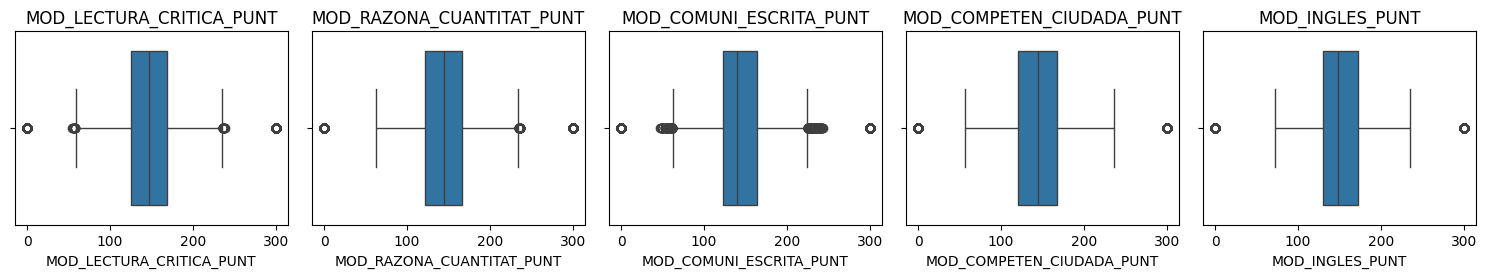

In [ ]:
# Valores atípicos (usando boxplots)
plt.figure(figsize=(15, 10))
for i, col in enumerate(df_cleaned_02[modulos]):
    plt.subplot(4, 5, i+1)
    sns.boxplot(x=df_cleaned_02[col])
    plt.title(col)
plt.tight_layout()
plt.show()